<img src="https://upload.wikimedia.org/wikipedia/commons/7/7c/Kaggle_logo.png" align="left" height=100 width=200>

🚀 [**`Kaggle - House prices, advanced regression techniques`**](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) 🚀

# 👋 Welcome to Kaggle!

* `Author` DavyDW

* `Inspired from`
    - [https://www.kaggle.com/code/jesucristo/1-house-prices-solution-top-1](https://www.kaggle.com/code/jesucristo/1-house-prices-solution-top-1)
    - [https://www.kaggle.com/code/ankitverma2010/house-price-prediction-ensemble-methods](https://www.kaggle.com/code/ankitverma2010/house-price-prediction-ensemble-methods)
    - **`TODO`** [https://www.kaggle.com/code/onehundreddays/house-prices-top-100-score](https://www.kaggle.com/code/onehundreddays/house-prices-top-100-score)
    - **`TODO`** [https://www.youtube.com/watch?v=UqmulHG4IvY](https://www.youtube.com/watch?v=UqmulHG4IvY)
        - [https://www.kaggle.com/code/ryannolan1/kaggle-housing-youtube-video](https://www.kaggle.com/code/ryannolan1/kaggle-housing-youtube-video)
    - **`TODO`** [https://www.kaggle.com/code/marweni/house-prices-complete-solution-with-guidance](https://www.kaggle.com/code/marweni/house-prices-complete-solution-with-guidance)
    - The solution provided by Bruno on Kitt

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/ML/kaggle-batch-challenge.png' width=600 align="left">

**Competition Description**

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

**Practice Skills**

* Creative feature engineering
* Advanced regression techniques like [`Random Forest Regressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html), [`Gradient Boosting Regressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) and [`XGBoost`](https://xgboost.readthedocs.io/en/stable/index.html)

**Acknowledgments**

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. It's an incredible alternative for data scientists looking for a modernized and expanded version of the often cited Boston Housing dataset.

# 📚 Libraries

In [ ]:
######################################
# Tools                              #
######################################
import warnings
warnings.filterwarnings("ignore")

######################################
# Data Manipulation                  #
######################################
import numpy as np
import pandas as pd
pd.options.display.max_columns = None

######################################
# Stats                              #
######################################
from scipy import stats
from statsmodels.graphics.gofplots import qqplot

######################################
# Data Visualisation                 #
######################################
import matplotlib.pyplot as plt
import seaborn as sns

######################################
# Machine Learning                   #
######################################

# Holdout, Cross Val
# ------------------------------------
from sklearn.model_selection import train_test_split, cross_validate

# Preprocessing
# ------------------------------------

## Imputers
from sklearn.impute import SimpleImputer, KNNImputer

## Scalers
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

## Encoders
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

## Pipeline and Column Transformers
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn import set_config; set_config(display="diagram")

## Custom Classes
from sklearn.base import TransformerMixin, BaseEstimator

## Caching operations
from tempfile import mkdtemp
from shutil import rmtree

# Feature selection
# ------------------------------------
from sklearn.feature_selection import mutual_info_regression, SelectPercentile

# Evaluation
# ------------------------------------

## Scoring Methods
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.model_selection import cross_validate, cross_val_score

## Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


# Regression Models
# ------------------------------------

## Linear
from sklearn.linear_model import Ridge, Lasso, LinearRegression, ElasticNet
from sklearn.linear_model import SGDRegressor

## Non-linear
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

## Support Vectors
from sklearn.svm import SVR

## Ensemble Methods
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor

## Masterpiece
from xgboost import XGBRegressor

## Catboost - TO DO

## LightGBM - TO DO

# 🏠 Load the <font color="blue">train</font> dataset

- `train.csv` is your `(1460, 81)` training set containing `X_train` and `y_train`
- `test.csv` is your `(1459, 80)` testing set with `X_test` but without the associated target `y_test` 😈
- `sample_submission.csv` describes the format required to submit your answer

ℹ️ You'll find a detailed description of the dataset [here](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/07-Ensemble-Methods/kaggle_houses_data_description.txt).

🎯 Your goal is to predict the `y_pred` missing from your test set and submit it to discover your `test_score` and ranking

❓ Load the training dataset into a DataFrame called `data`, and create your `X` and `y`. Inspect their shapes.

**Hint:** if you check the CSV file, you will notice a column called `Id`. When reading the CSV file into a DF, make sure to set `index_col="Id"` so that you don't get two ID columns 😉

In [ ]:
##############
# TRAIN SET  #
##############
data_train = pd.read_csv('https://wagon-public-datasets.s3.amazonaws.com/houses_train_raw.csv', index_col='Id')
data_train.shape

(1460, 80)

In [ ]:
data_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
#############
# TEST SET  #
#############
X_test = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/houses_test_raw.csv")
X_test_ids = X_test['Id'] # Keep ids
X_test = X_test.drop(columns=['Id'])
X_test.shape

(1459, 79)

# 🐣 BASELINE

In [ ]:
X_train = data_train.drop(columns=["SalePrice"])
y_train = data_train["SalePrice"]

In [ ]:
# 79 features...
X_train.dtypes.value_counts()

,count
object,43
int64,33
float64,3


<Axes: ylabel='count'>

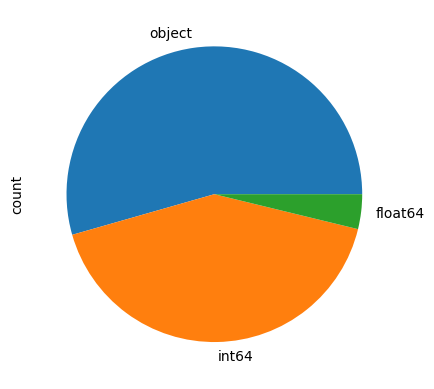

In [ ]:
X_train.dtypes.value_counts().plot(kind="pie")

In [ ]:
X_train.select_dtypes(include=["object"]).nunique().sort_values(ascending=False)

,0
Neighborhood,25
Exterior2nd,16
Exterior1st,15
SaleType,9
Condition1,9
Condition2,8
HouseStyle,8
RoofMatl,8
Functional,7
BsmtFinType2,6


In [ ]:
# 43 categorical values... will be a lot if we encode them all
categorical_features_unique = X_train.select_dtypes(include=["object"]).nunique()
categorical_features_unique.sum()

# X_train.select_dtypes(include=["object"]).nunique().sort_values(ascending=False)

251

🔗 [datascience.stackexchange.com - any rules of thumb on number of features vs number of instances?](https://datascience.stackexchange.com/questions/11390/any-rules-of-thumb-on-number-of-features-versus-number-of-instances-small-da/11480#11480)

In [ ]:
# Let's drop columns with too many unique values for our baseline model
threshold = 7
categorical_features_small = categorical_features_unique[categorical_features_unique.\
                                                         sort_values(ascending=False)<threshold]
categorical_features_small.sort_values(ascending=False)

,0
BsmtFinType1,6
RoofStyle,6
GarageType,6
Heating,6
BsmtFinType2,6
Foundation,6
SaleCondition,6
HeatingQC,5
BldgType,5
GarageCond,5


In [ ]:
len(categorical_features_small)

34

In [ ]:
categorical_features_small.sort_values(ascending=False).sum()

146

In [ ]:
X_train.select_dtypes(include=np.number).shape[-1]

36

## (1) Basic Preprocessor without EDA

In [ ]:
preproc_numerical_baseline = make_pipeline(
    SimpleImputer(),
    MinMaxScaler()
)

preproc_numerical_baseline

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('minmaxscaler', MinMaxScaler())])

In [ ]:
# X_train.select_dtypes(include=["int64", "float64"])
# preproc_numerical_baseline.fit_transform(X_train.select_dtypes(include=np.number)).head() #SUCCESS

In [ ]:
preproc_categorical_baseline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
)

preproc_categorical_baseline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(drop='if_binary', handle_unknown='ignore',
                               sparse_output=False))])

In [ ]:
# X_train.select_dtypes(exclude=["int64", "float64"])
# preproc_categorical_baseline.fit_transform(X_train.select_dtypes(exclude=np.number)).head()

In [ ]:
# preproc_baseline = make_column_transformer(
#     (preproc_numerical_baseline, make_column_selector(dtype_include=["int64", "float64"])),
#     (preproc_categorical_baseline, categorical_features_small),
#     remainder="drop"
# ).set_output(transform="pandas")


preproc_baseline = ColumnTransformer([
    ("num_transfo", preproc_numerical_baseline, make_column_selector(dtype_include=np.number)), # NUM PIPELINE
    ("cat_transfo", preproc_categorical_baseline, make_column_selector(dtype_exclude=np.number))  # CAT PIPELINE
]).set_output(transform="pandas")

In [ ]:
preproc_baseline

ColumnTransformer(transformers=[('num_transfo',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7a80c3da1390>),
                                ('cat_transfo',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7a80c383fa50>)])

In [ ]:
preproc_baseline.fit_transform(X_train)

,num_transfo__MSSubClass,num_transfo__LotFrontage,num_transfo__LotArea,num_transfo__OverallQual,num_transfo__OverallCond,num_transfo__YearBuilt,num_transfo__YearRemodAdd,num_transfo__MasVnrArea,num_transfo__BsmtFinSF1,num_transfo__BsmtFinSF2,num_transfo__BsmtUnfSF,num_transfo__TotalBsmtSF,num_transfo__1stFlrSF,num_transfo__2ndFlrSF,num_transfo__LowQualFinSF,num_transfo__GrLivArea,num_transfo__BsmtFullBath,num_transfo__BsmtHalfBath,num_transfo__FullBath,num_transfo__HalfBath,num_transfo__BedroomAbvGr,num_transfo__KitchenAbvGr,num_transfo__TotRmsAbvGrd,num_transfo__Fireplaces,num_transfo__GarageYrBlt,num_transfo__GarageCars,num_transfo__GarageArea,num_transfo__WoodDeckSF,num_transfo__OpenPorchSF,num_transfo__EnclosedPorch,num_transfo__3SsnPorch,num_transfo__ScreenPorch,num_transfo__PoolArea,num_transfo__MiscVal,num_transfo__MoSold,num_transfo__YrSold,cat_transfo__MSZoning_C (all),cat_transfo__MSZoning_FV,cat_transfo__MSZoning_RH,cat_transfo__MSZoning_RL,cat_transfo__MSZoning_RM,cat_transfo__Street_Pave,cat_transfo__Alley_Pave,cat_transfo__LotShape_IR1,cat_transfo__LotShape_IR2,cat_transfo__LotShape_IR3,cat_transfo__LotShape_Reg,cat_transfo__LandContour_Bnk,cat_transfo__LandContour_HLS,cat_transfo__LandContour_Low,cat_transfo__LandContour_Lvl,cat_transfo__Utilities_NoSeWa,cat_transfo__LotConfig_Corner,cat_transfo__LotConfig_CulDSac,cat_transfo__LotConfig_FR2,cat_transfo__LotConfig_FR3,cat_transfo__LotConfig_Inside,cat_transfo__LandSlope_Gtl,cat_transfo__LandSlope_Mod,cat_transfo__LandSlope_Sev,cat_transfo__Neighborhood_Blmngtn,cat_transfo__Neighborhood_Blueste,cat_transfo__Neighborhood_BrDale,cat_transfo__Neighborhood_BrkSide,cat_transfo__Neighborhood_ClearCr,cat_transfo__Neighborhood_CollgCr,cat_transfo__Neighborhood_Crawfor,cat_transfo__Neighborhood_Edwards,cat_transfo__Neighborhood_Gilbert,cat_transfo__Neighborhood_IDOTRR,cat_transfo__Neighborhood_MeadowV,cat_transfo__Neighborhood_Mitchel,cat_transfo__Neighborhood_NAmes,cat_transfo__Neighborhood_NPkVill,cat_transfo__Neighborhood_NWAmes,cat_transfo__Neighborhood_NoRidge,cat_transfo__Neighborhood_NridgHt,cat_transfo__Neighborhood_OldTown,cat_transfo__Neighborhood_SWISU,cat_transfo__Neighborhood_Sawyer,cat_transfo__Neighborhood_SawyerW,cat_transfo__Neighborhood_Somerst,cat_transfo__Neighborhood_StoneBr,cat_transfo__Neighborhood_Timber,cat_transfo__Neighborhood_Veenker,cat_transfo__Condition1_Artery,cat_transfo__Condition1_Feedr,cat_transfo__Condition1_Norm,cat_transfo__Condition1_PosA,cat_transfo__Condition1_PosN,cat_transfo__Condition1_RRAe,cat_transfo__Condition1_RRAn,cat_transfo__Condition1_RRNe,cat_transfo__Condition1_RRNn,cat_transfo__Condition2_Artery,cat_transfo__Condition2_Feedr,cat_transfo__Condition2_Norm,cat_transfo__Condition2_PosA,cat_transfo__Condition2_PosN,cat_transfo__Condition2_RRAe,cat_transfo__Condition2_RRAn,cat_transfo__Condition2_RRNn,cat_transfo__BldgType_1Fam,cat_transfo__BldgType_2fmCon,cat_transfo__BldgType_Duplex,cat_transfo__BldgType_Twnhs,cat_transfo__BldgType_TwnhsE,cat_transfo__HouseStyle_1.5Fin,cat_transfo__HouseStyle_1.5Unf,cat_transfo__HouseStyle_1Story,cat_transfo__HouseStyle_2.5Fin,cat_transfo__HouseStyle_2.5Unf,cat_transfo__HouseStyle_2Story,cat_transfo__HouseStyle_SFoyer,cat_transfo__HouseStyle_SLvl,cat_transfo__RoofStyle_Flat,cat_transfo__RoofStyle_Gable,cat_transfo__RoofStyle_Gambrel,cat_transfo__RoofStyle_Hip,cat_transfo__RoofStyle_Mansard,cat_transfo__RoofStyle_Shed,cat_transfo__RoofMatl_ClyTile,cat_transfo__RoofMatl_CompShg,cat_transfo__RoofMatl_Membran,cat_transfo__RoofMatl_Metal,cat_transfo__RoofMatl_Roll,cat_transfo__RoofMatl_Tar&Grv,cat_transfo__RoofMatl_WdShake,cat_transfo__RoofMatl_WdShngl,cat_transfo__Exterior1st_AsbShng,cat_transfo__Exterior1st_AsphShn,cat_transfo__Exterior1st_BrkComm,cat_transfo__Exterior1st_BrkFace,cat_transfo__Exterior1st_CBlock,cat_transfo__Exterior1st_CemntBd,cat_transfo__Exterior1st_HdBoard,cat_transfo__Exterior1st_ImStucc,cat_transfo__Exterior1st_MetalSd,cat_transfo__Exterior1st_Plywood,cat_transfo__Exter

## (2) Pipelined Estimator

In [ ]:
pipeline_baseline = make_pipeline(preproc_baseline,
                                  DecisionTreeRegressor())
pipeline_baseline

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num_transfo',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a80c3da1390>),
                                                 ('cat_transfo',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7a80c383fa50>)])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

## (3) Scoring metrics

🔗 [Contest Evaluation Rules](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview/evaluation)

> Metric
Submissions are evaluated on **Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price.** (Taking logs means that errors in predicting expensive houses and cheap houses will affect the result equally.)

---

🧮 **RMSLE formula**

$$\text{RMSLE}(y, \hat{y}) = \sqrt{\frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} \big(\log_e (1 + y_i) - \log_e (1 + \hat{y}_i) \big)^2.}$$

---

We will need to create our own custom `sklearn.metrics.scorer` object to be passed to any CrossValidation, GridSearchCV, Randomized. The process is described as follows:


1. Create a scorer called `rmsle` using [`make_scorer`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) that can be passed as a value for the `scoring` `kwarg`:  
    ```python
    cross_val_score(pipe_baseline, X, y, cv=5, scoring=rmsle)
    ```
2.  Create its negative counterpart, `rmsle_neg`, which is best when _maximized_; this will come in handy later as `GridSearchCV` always tries to _maximize_ a score 😉
    ```python
    GridSearchCV(pipe_baseline, param_grid=..., cv=5, scoring=rmsle_neg)
    ```
    

### RMSLE

In [ ]:
from sklearn.metrics import root_mean_squared_log_error
from sklearn.metrics import make_scorer

#######################################
# OPTION 1: recode it all manually    #
#######################################
# def root_mean_squared_log_error(y_true, y_pred):
#     t = np.array(y_true)
#     p = np.array(y_pred)

#     log_error = np.log(1+t) - np.log(1+p)

#     return ((log_error**2).mean())**0.5

# # This is our metric to minimize
# rmsle = make_scorer(root_mean_squared_log_error)

# # This is our score to maximize
# rmsle_neg = make_scorer(lambda y_true, y_pred: -1 * root_mean_squared_log_error(y_true, y_pred))

#######################################
# OPTION 2: re-use Sklearn MSLE       #
#######################################

# LOG
# ---------------------------------------

# This is our metric to minimize
rmsle = make_scorer(lambda y_true, y_pred: mean_squared_log_error(y_true, y_pred)**0.5)

# This is our score to maximize
rmsle_neg = make_scorer(lambda y_true, y_pred: -1 * mean_squared_log_error(y_true, y_pred)**0.5)

# Equivalent formulation for the rmsle_neg
rmsle_neg = make_scorer(
    lambda y_true, y_pred: mean_squared_log_error(y_true, y_pred)**0.5,
    greater_is_better=False
)

In [ ]:
rmsle_davy = make_scorer(lambda y_true, y_pred: root_mean_squared_log_error(y_true, y_pred))
rmsle_davy_neg = make_scorer(lambda y_true, y_pred: -root_mean_squared_log_error(y_true, y_pred))
rmsle_davy_neg_v2 = make_scorer(lambda y_true, y_pred: root_mean_squared_log_error(y_true, y_pred),
                                                                                   greater_is_better=False)

### RMSE

In [ ]:
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import make_scorer

# NON-LOG
# ---------------------------------------

# Equivalent formulation for the rmse_neg
rmse_neg = make_scorer(
    lambda y_log_true, y_log_pred: mean_squared_error(y_log_true, y_log_pred)**0.5,
    greater_is_better=False
)

## (4) Cross-Validating the Pipelined Model

In [ ]:
# score_baseline = cross_val_score(pipeline_baseline, X_train, y_train, cv=5, scoring=rmsle).mean()

score_baseline = cross_val_score(pipeline_baseline, X_train, y_train, cv=5, scoring=rmsle_davy).mean()
round(score_baseline,3)

0.205

# 🕵🏻‍♂️ EDA

## (1) Features

In [ ]:
# 🚮 DROP DUPLICATES
print(f"Original train dataset, shape = {data_train.shape}")

data_train = data_train.drop_duplicates()
print(f"Train dataset without duplicates, shape = {data_train.shape[0]} houses, {data_train.shape[1]-1 } features, 1 target")

Original train dataset, shape = (1460, 80)
Train dataset without duplicates, shape = 1460 houses, 79 features, 1 target


In [ ]:
# 🎯 DEFINING FEATURES AND TARGET
X_train = data_train.drop(columns=["SalePrice"])
y_train = data_train["SalePrice"]

,count
object,43
int64,33
float64,3


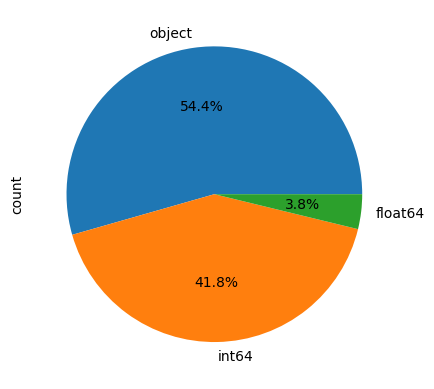

In [ ]:
# DTYPES
display(X_train.dtypes.value_counts())
# CUTIE PIE
X_train.dtypes.value_counts().plot(kind="pie", autopct='%1.1f%%');

In [ ]:
# NUMERICAL FEATURES
numerical_features = X_train.select_dtypes(include=["int64","float64"]).columns
print(f"There are {len(numerical_features)} numerical features:")
display(numerical_features)

There are 36 numerical features:


Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [ ]:
# CATEGORICAL FEATURES
categorical_features = X_train.select_dtypes(include=["object"]).columns
print(f"There are {len(categorical_features)} categorical features:")
display(categorical_features)

There are 43 categorical features:


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

## (2) Target

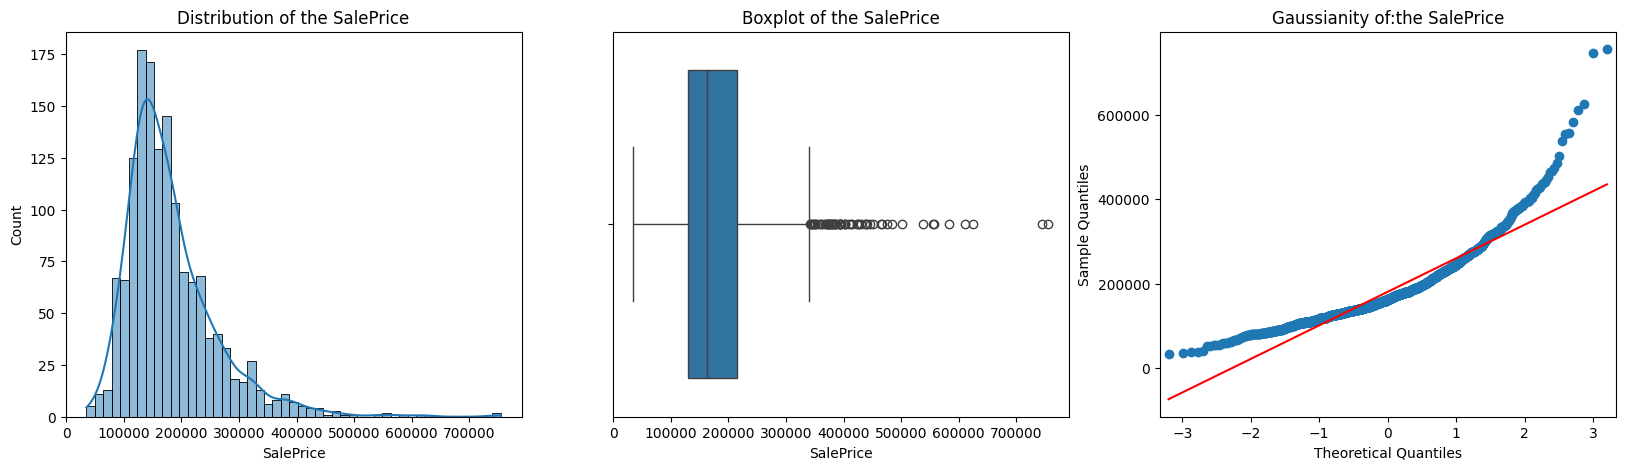

In [ ]:
variable = 'SalePrice'
y_train = data_train[f"{variable}"]

fig, ax = plt.subplots(1,3,figsize=(20,5))

ax[0].set_title(f"Distribution of the {variable}")
sns.histplot(data = data_train, x = f"{variable}", kde=True, ax = ax[0])

ax[1].set_title(f"Boxplot of the {variable}")
sns.boxplot(data = data_train, x = f"{variable}", ax=ax[1])

ax[2].set_title(f"Gaussianity of:the {variable}")
qqplot(data_train[f"{variable}"],line='s',ax=ax[2]);

In [ ]:
Q1 = y_train.describe()["25%"]
Q3 = y_train.describe()["75%"]

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Houses are priced mostly under {round(upper_bound)} USD")

Houses are priced mostly under 340038 USD


In [ ]:
luxury_mask = data_train["SalePrice"] > upper_bound
luxury_houses = data_train[luxury_mask]

print(f"Luxury houses represent {round(luxury_houses.shape[0]/len(data_train),2)*100} % of the dataset")


Luxury houses represent 4.0 % of the dataset


## (3) Log(Target)

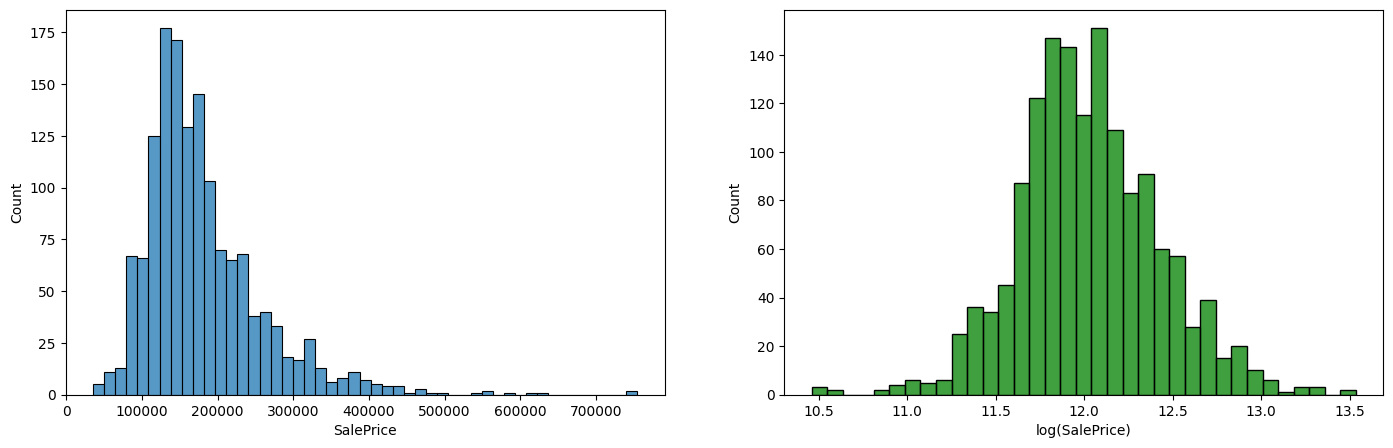

In [ ]:
data_train["LogSalePrice"] = np.log(1 + data_train["SalePrice"])

plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
sns.histplot(data_train["SalePrice"])

plt.subplot(1, 2, 2)
sns.histplot(data_train["LogSalePrice"], color='green')

plt.xlabel("log(SalePrice)")

plt.show();

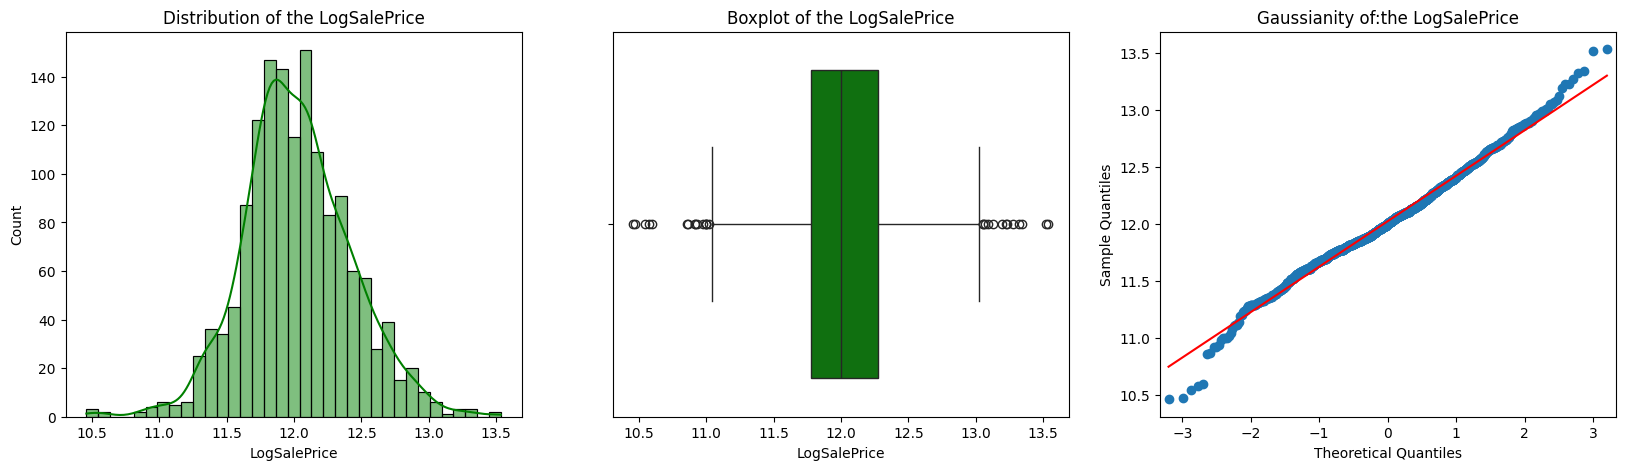

In [ ]:
variable = 'LogSalePrice'
y_train_log = data_train[f"{variable}"]

fig, ax = plt.subplots(1,3,figsize=(20,5))

ax[0].set_title(f"Distribution of the {variable}")
sns.histplot(data = data_train, x = f"{variable}", kde=True, ax = ax[0], color="green")

ax[1].set_title(f"Boxplot of the {variable}")
sns.boxplot(data = data_train, x = f"{variable}", ax=ax[1], color="green")

ax[2].set_title(f"Gaussianity of:the {variable}")
qqplot(data_train[f"{variable}"],line='s',ax=ax[2], c="green");

In [ ]:
Q1_log = data_train['LogSalePrice'].describe()["25%"]
Q3_log = data_train['LogSalePrice'].describe()["75%"]

IQR_log = Q3_log - Q1_log
lower_bound_log = Q1_log - 1.5 * IQR_log
upper_bound_log = Q3_log + 1.5 * IQR_log

cheap_mask_log = data_train['LogSalePrice'] < lower_bound_log
cheap_houses_log = data_train[cheap_mask_log]

luxury_mask_log = data_train['LogSalePrice'] > upper_bound_log
luxury_houses_log = data_train[luxury_mask_log]

nb_outliers_log = len(cheap_houses_log) + len(luxury_houses_log)

print(f"Outlier houses represent {round(nb_outliers_log/len(data_train),2)*100} % of the dataset")

Outlier houses represent 2.0 % of the dataset


## (4) Potential impact of each feature on the target

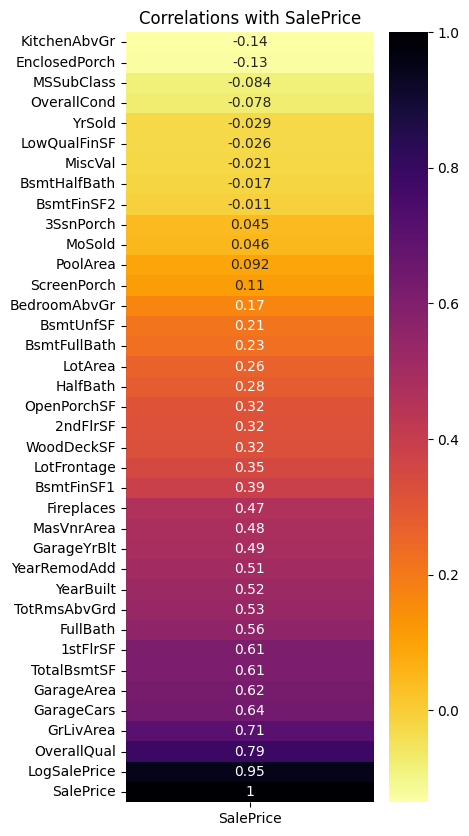

In [ ]:
plt.figure(figsize=(4,10))
sns.heatmap(data_train.select_dtypes(include=np.number).corr()[['SalePrice']].sort_values(by="SalePrice",ascending=True),
            annot=True,
            cmap="inferno_r")
plt.title('Correlations with SalePrice')
plt.show()

# 🛠️ PREPROCESSOR

## ❓ Missing Values

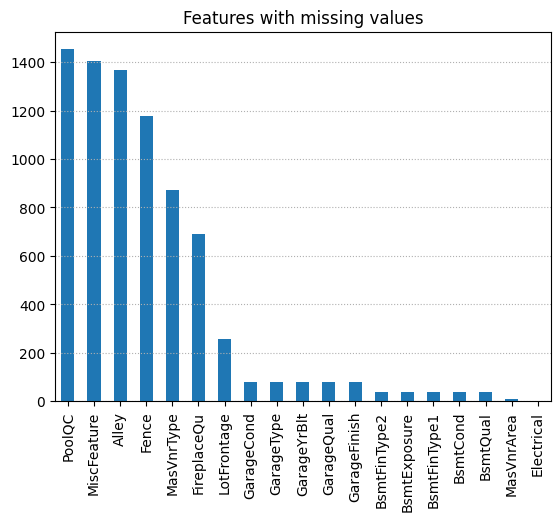

In [ ]:
# MISSING VALUES
missing_mask = X_train.isna().sum() > 0
missing_values = X_train.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_mask]
missing_values.plot(kind="bar")

plt.grid(axis="y", linestyle=":")
plt.title("Features with missing values")
plt.show();

# STORING FEATURES WITH MISSING VALUES IN A LIST
incomplete_features = missing_values.index

## 🔢 Numerical Features

In [ ]:
numerical_features = X_train.select_dtypes(exclude = ["object"]).columns
numerical_features

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [ ]:
X_train_num = X_train[numerical_features]
X_train_num.shape

(1460, 36)

### ⏰ Cyclical features

In [ ]:
class CyclicalFeatures(TransformerMixin, BaseEstimator):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        sin =  np.sin(2 * np.pi * (X.MoSold - 1) / 12)
        cos = np.cos(2 * np.pi * (X.MoSold - 1) / 12)
        self.transformed = pd.DataFrame({'sin_MoSold':sin,
                             'cos_MoSold':cos})
        return self.transformed.reset_index(drop=True)

    def get_feature_names_out(self):
        return self.columns


In [ ]:
cyclical_features = ["MoSold"]

In [ ]:
cyclical_features_transformed = CyclicalFeatures().fit_transform(X_train)
cyclical_features_transformed

,sin_MoSold,cos_MoSold
0,0.500000,8.660254e-01
1,0.866025,-5.000000e-01
2,-0.866025,-5.000000e-01
3,0.500000,8.660254e-01
4,-0.500000,8.660254e-01
...,...,...
1455,-0.500000,-8.660254e-01
1456,0.500000,8.660254e-01
1457,0.866025,-5.000000e-01
1458,1.000000,6.123234e-17


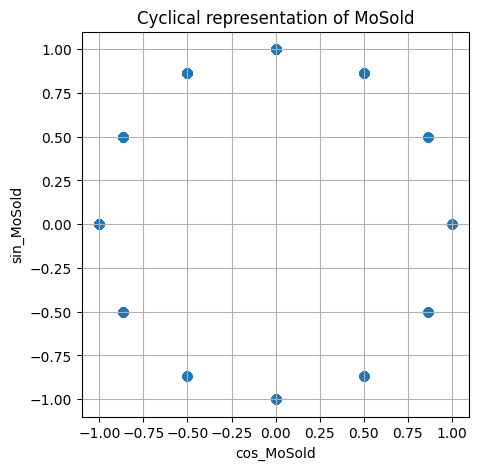

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(cyclical_features_transformed["cos_MoSold"], cyclical_features_transformed["sin_MoSold"])
plt.title("Cyclical representation of MoSold")
plt.xlabel("cos_MoSold")
plt.ylabel("sin_MoSold")
plt.grid()

### ⚖️ Scaling features

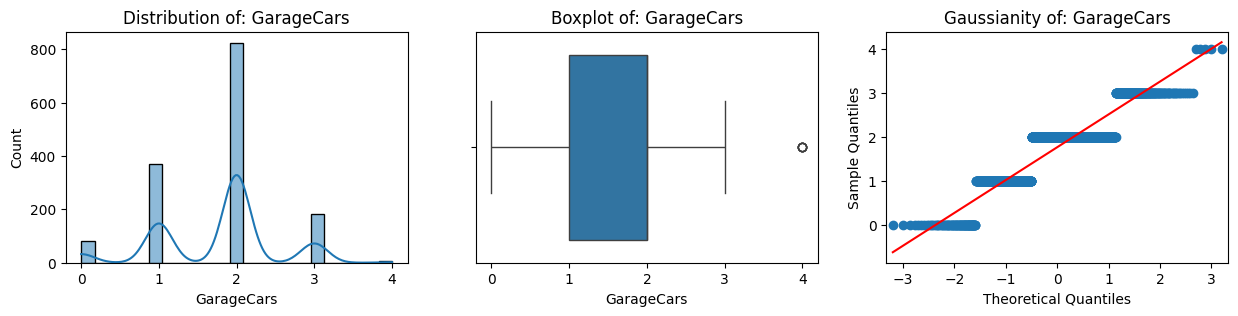

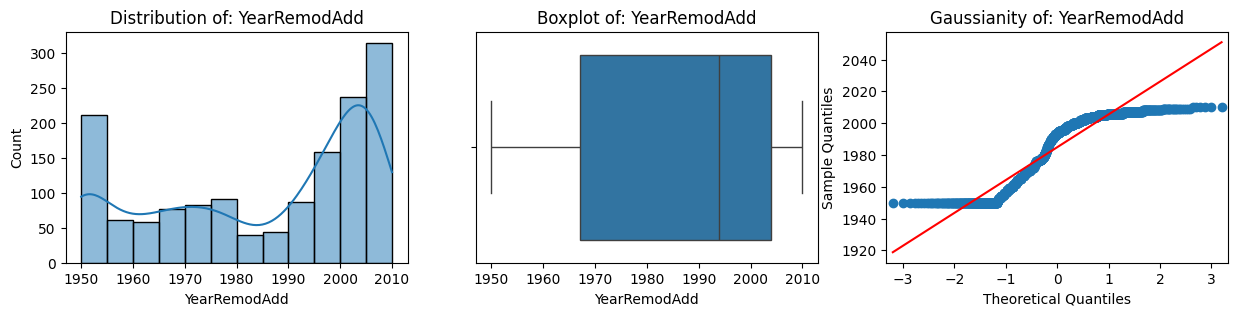

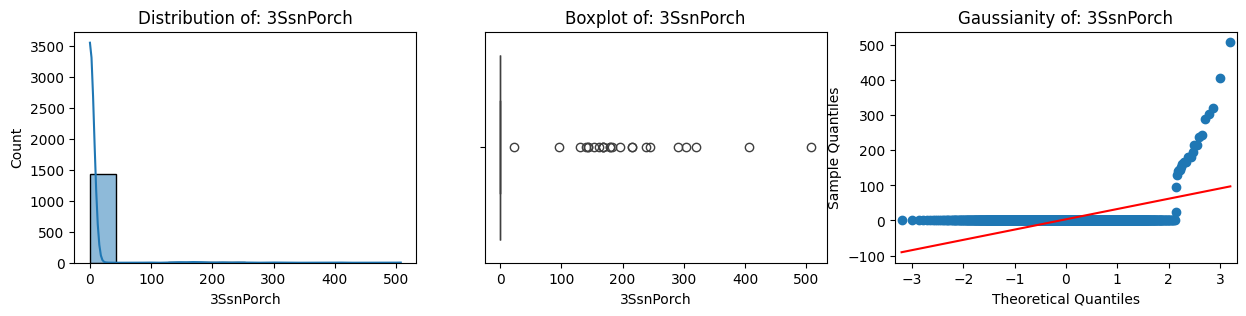

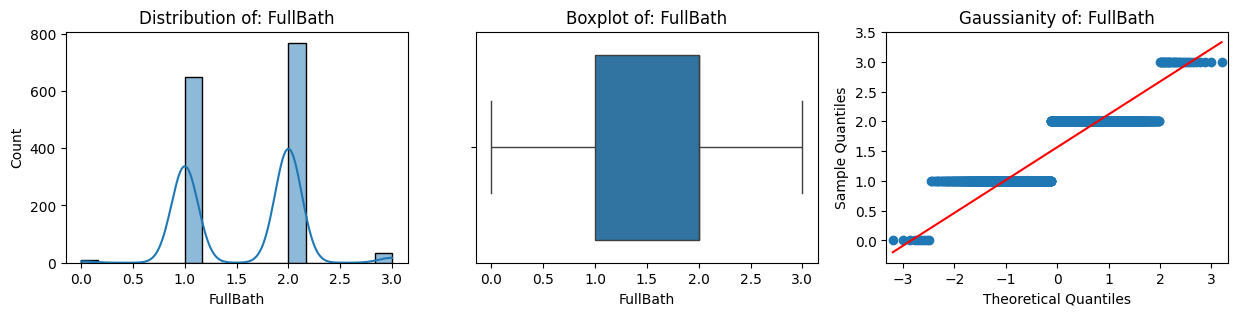

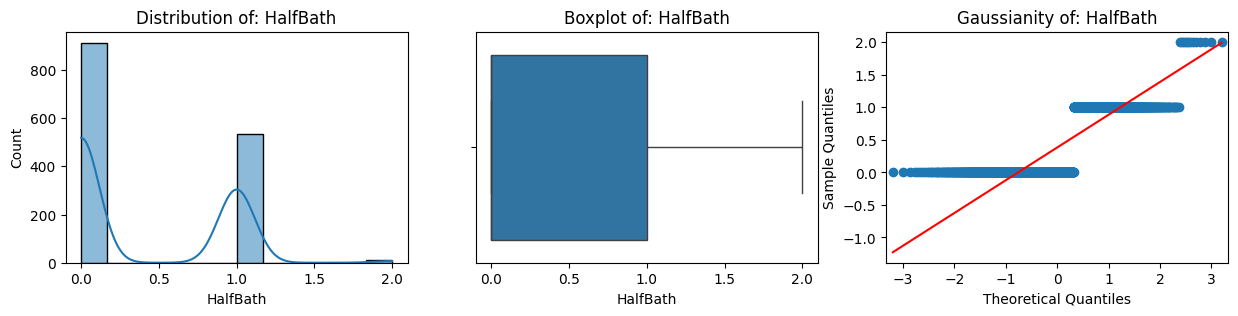

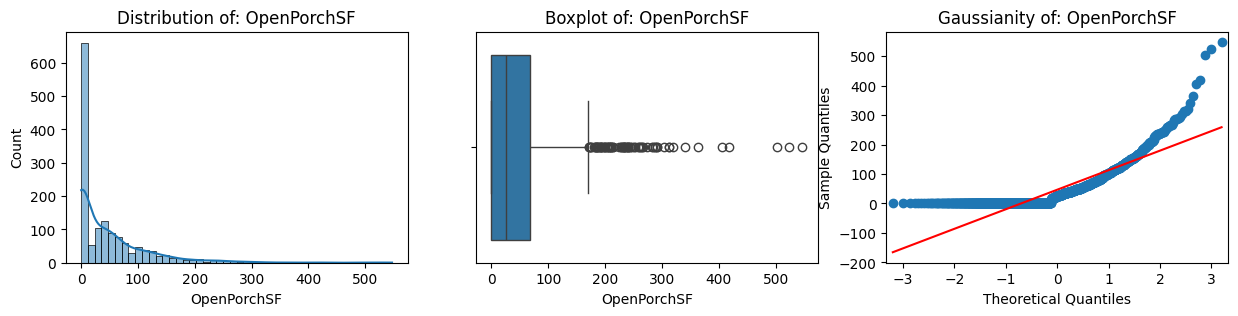

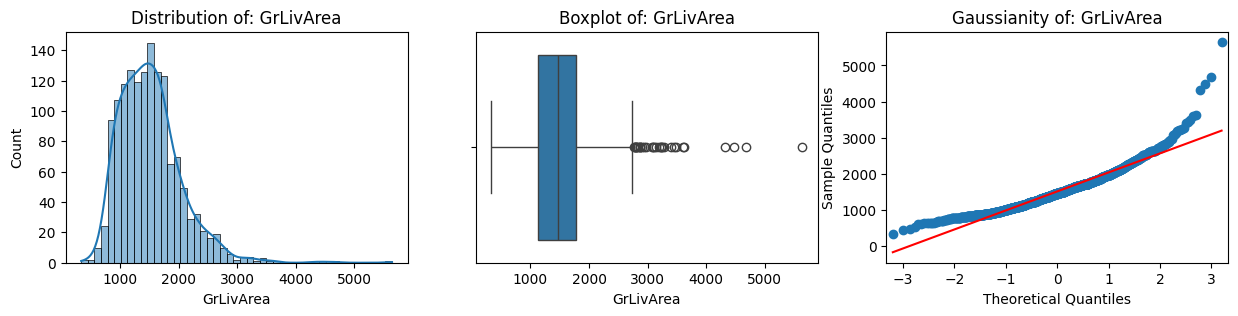

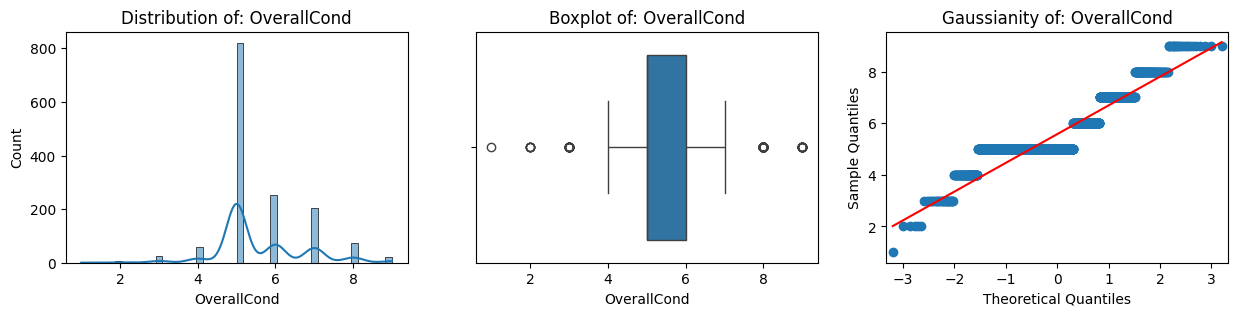

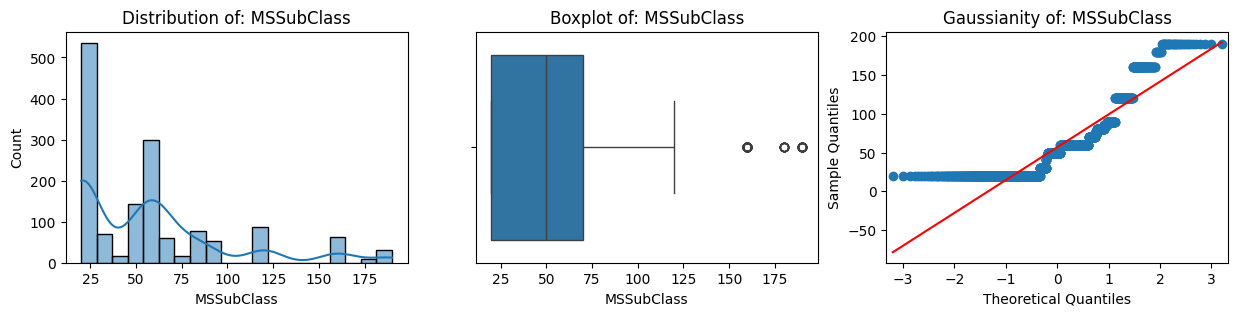

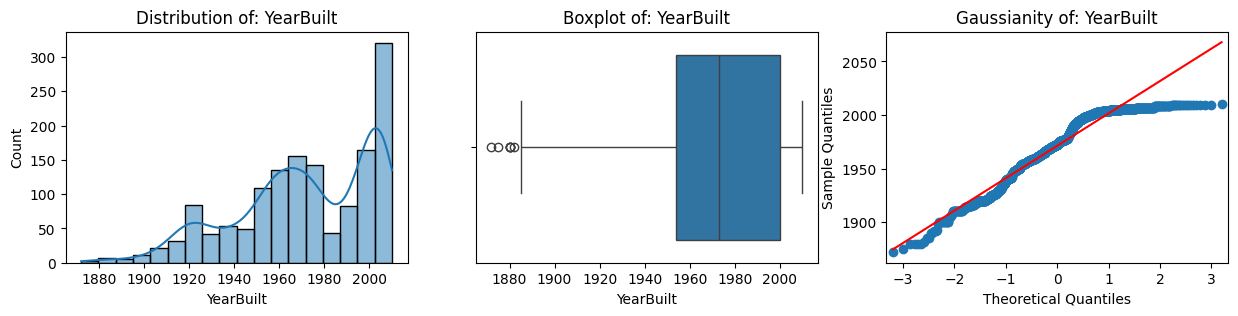

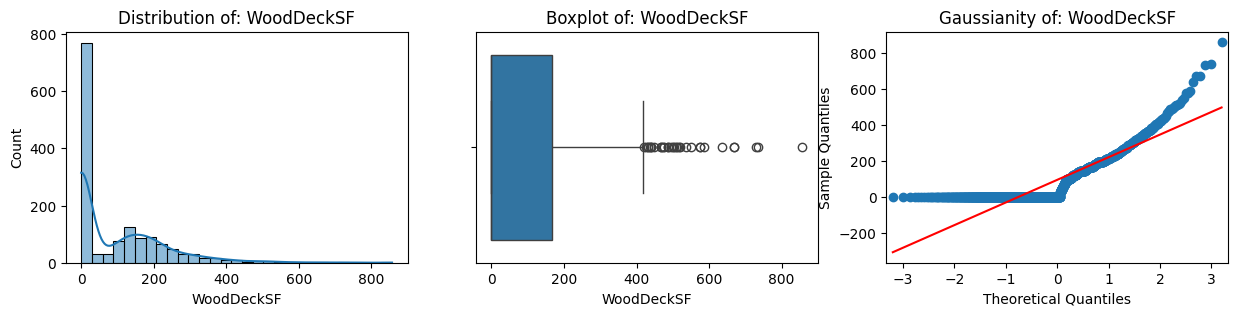

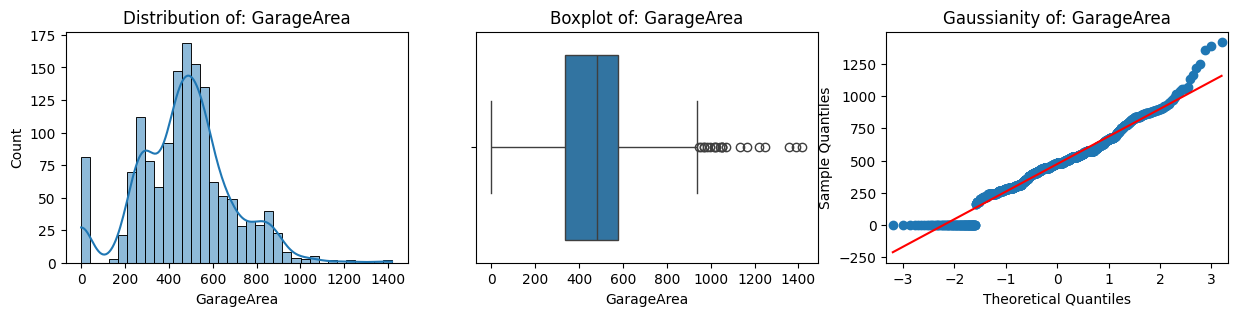

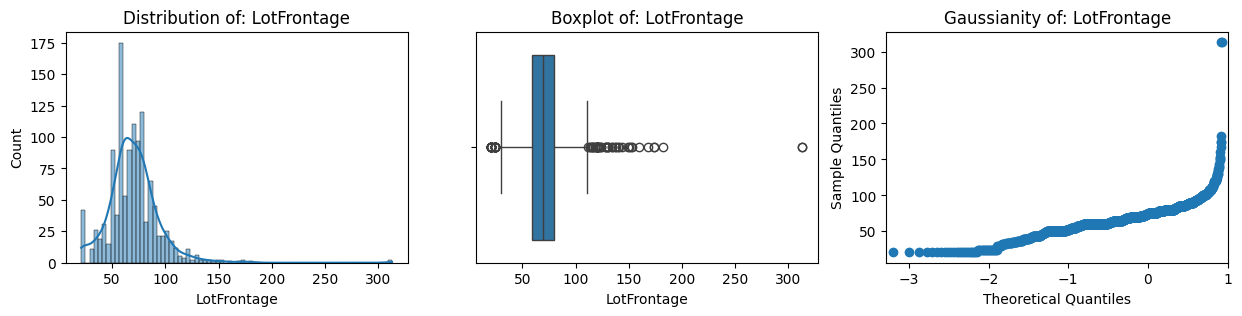

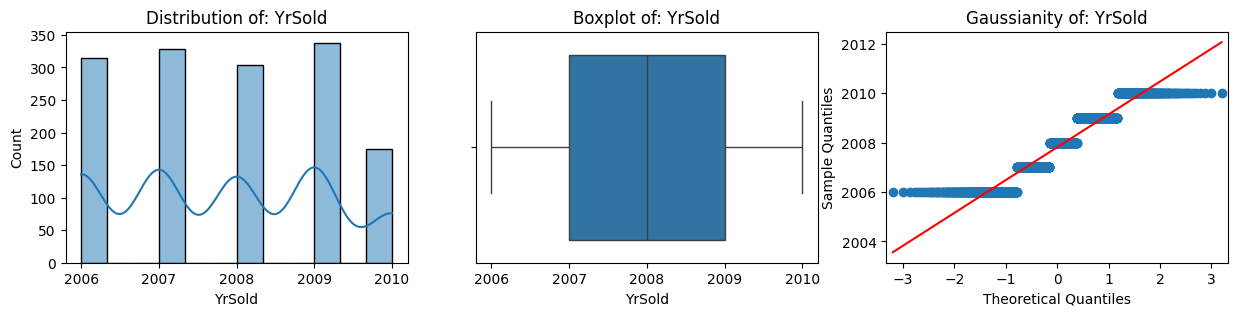

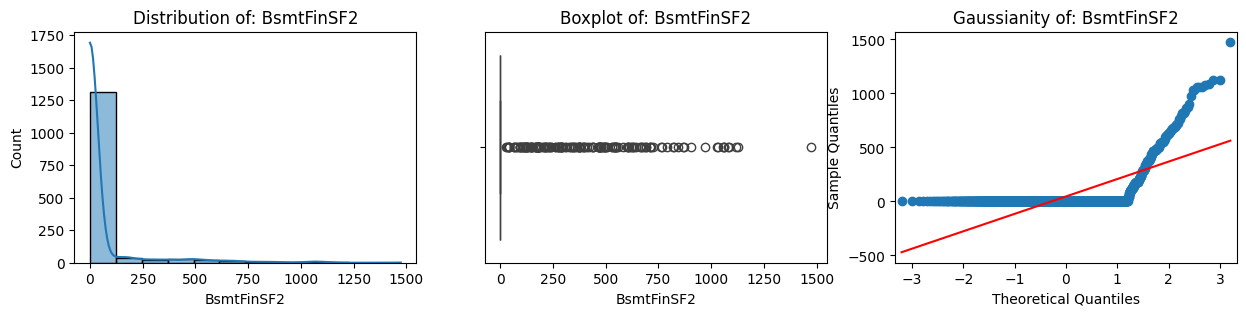

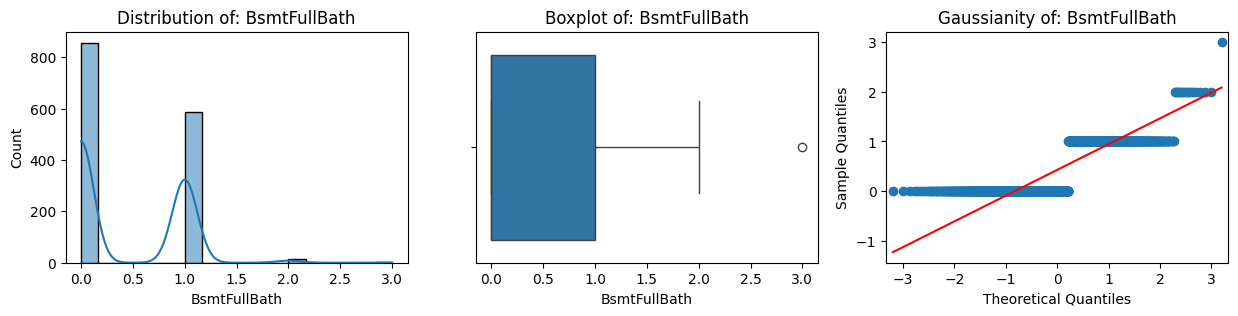

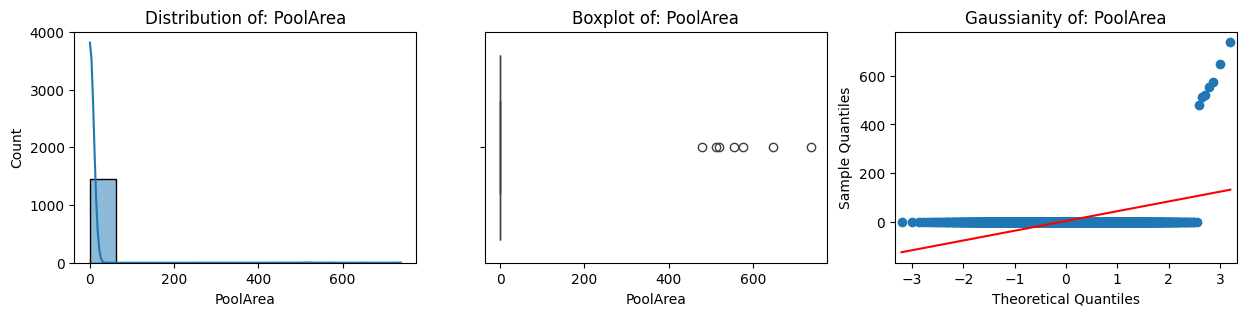

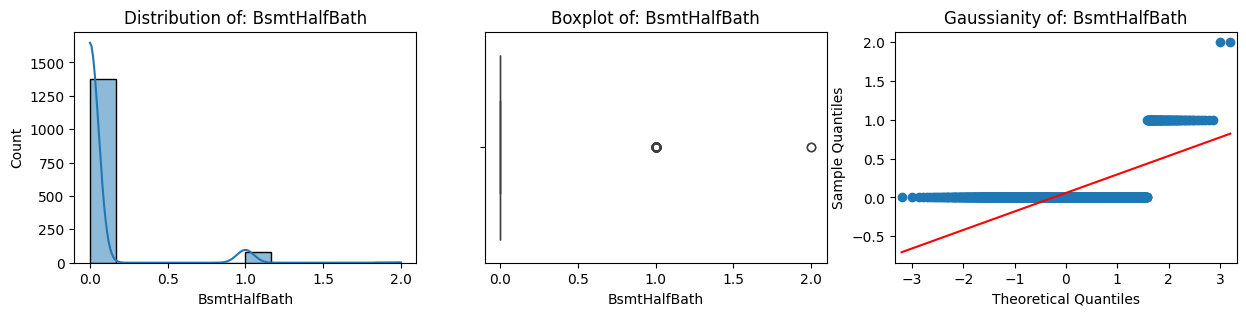

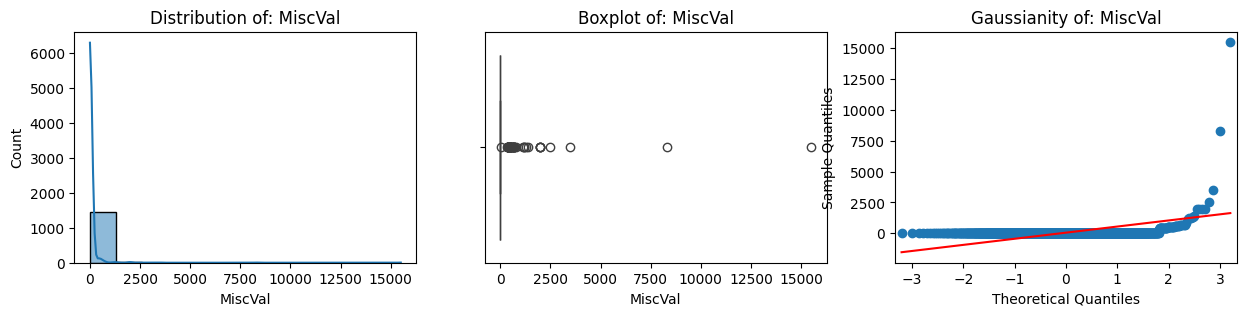

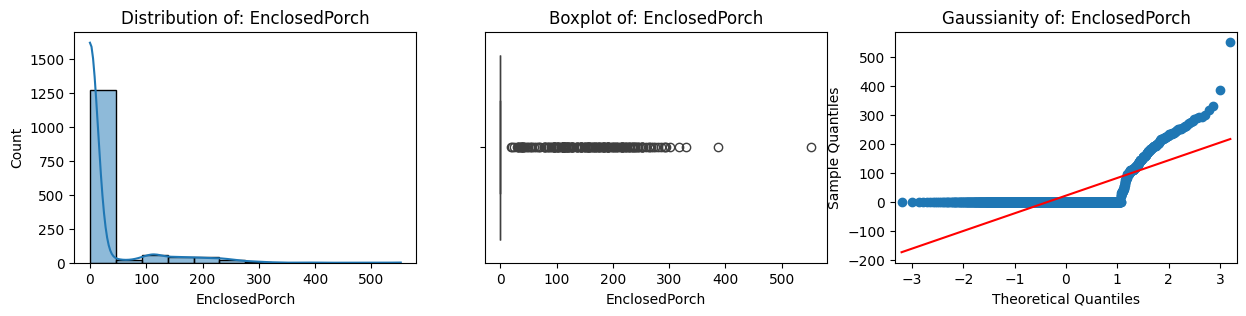

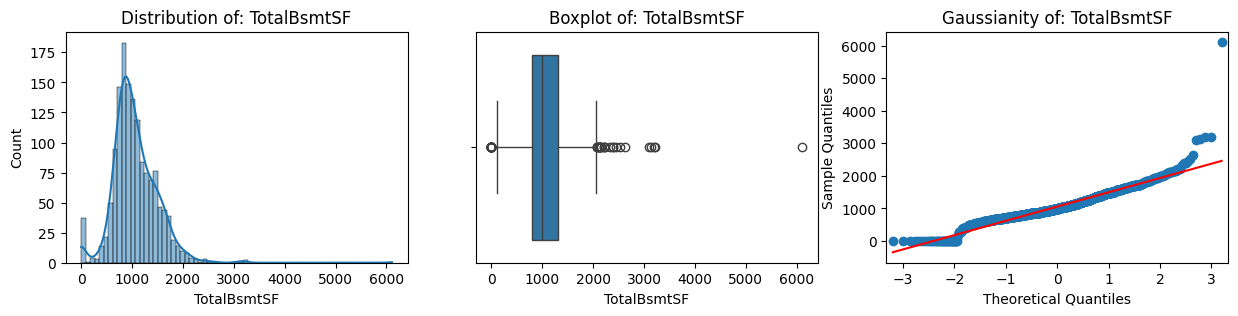

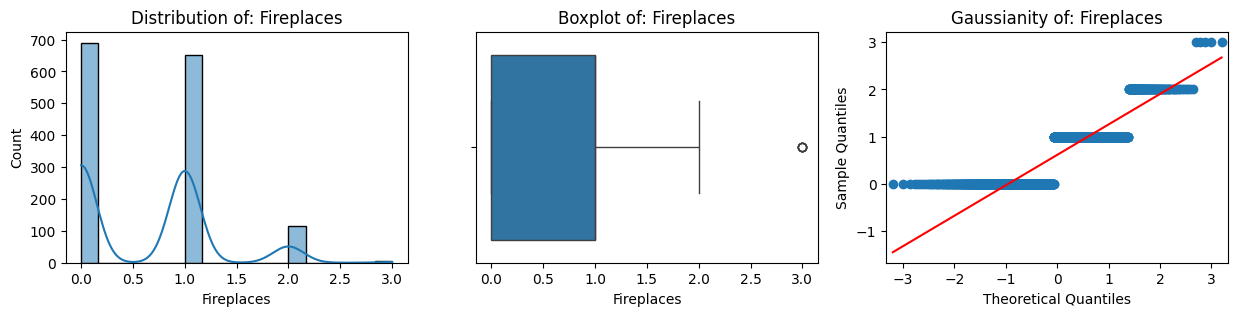

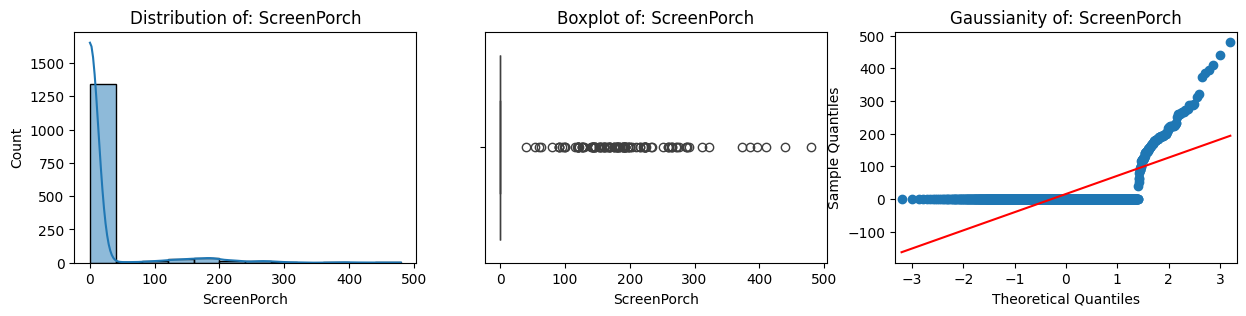

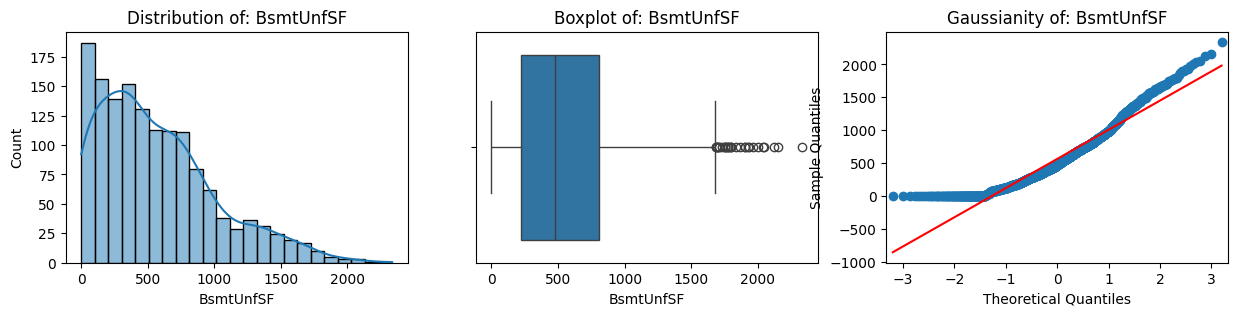

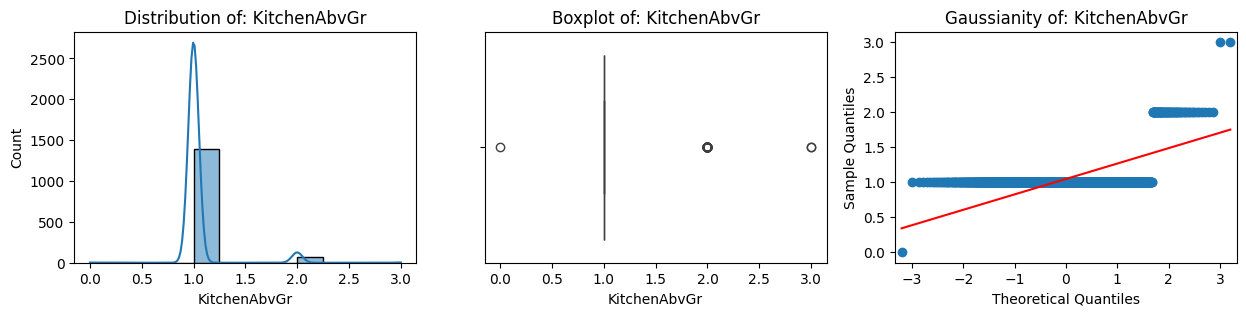

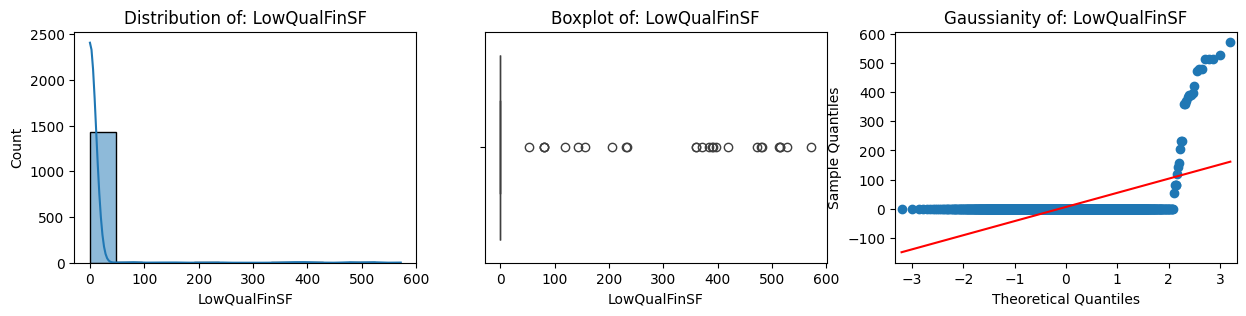

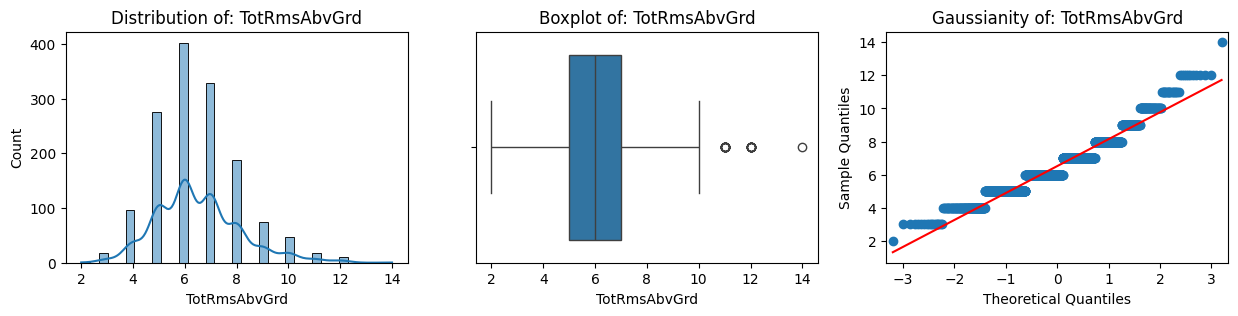

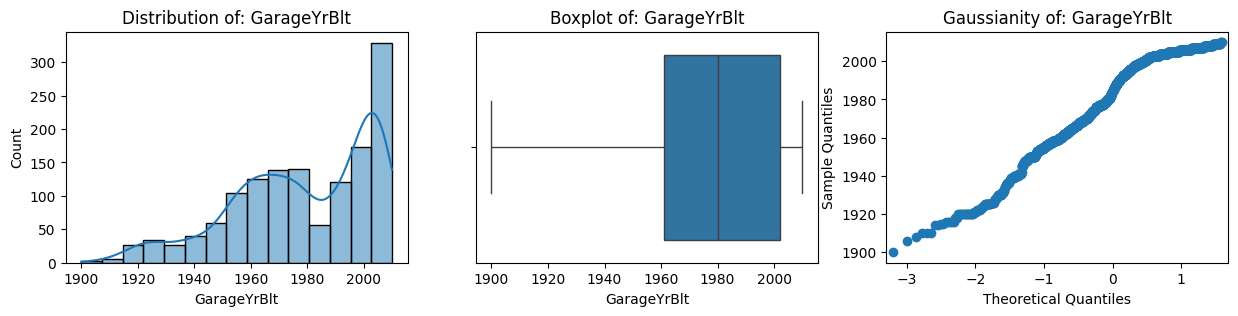

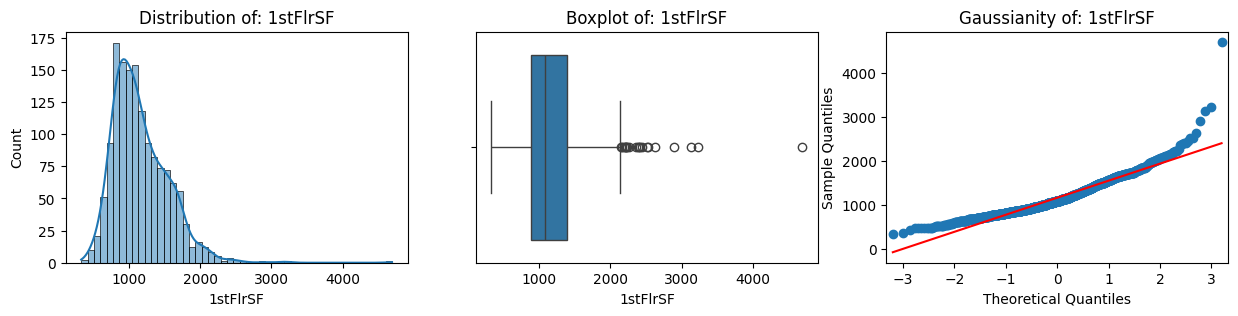

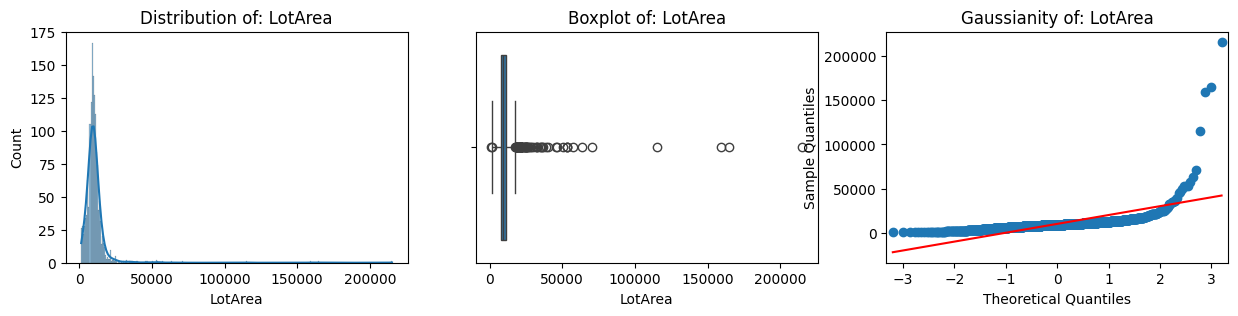

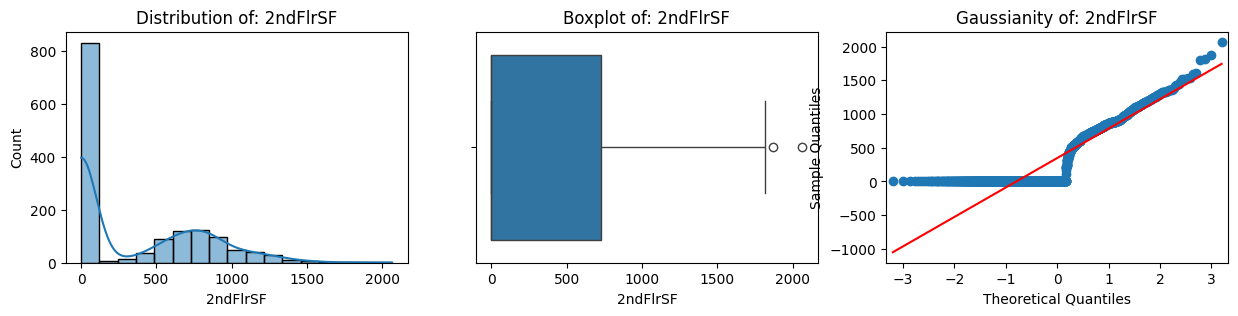

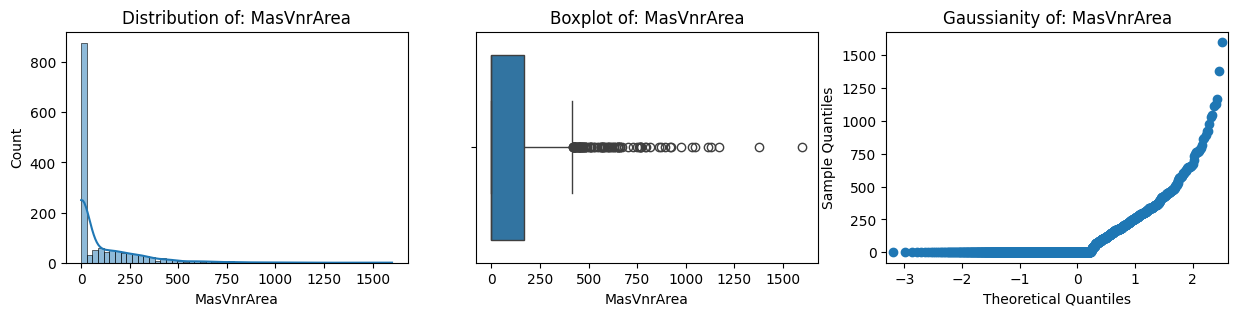

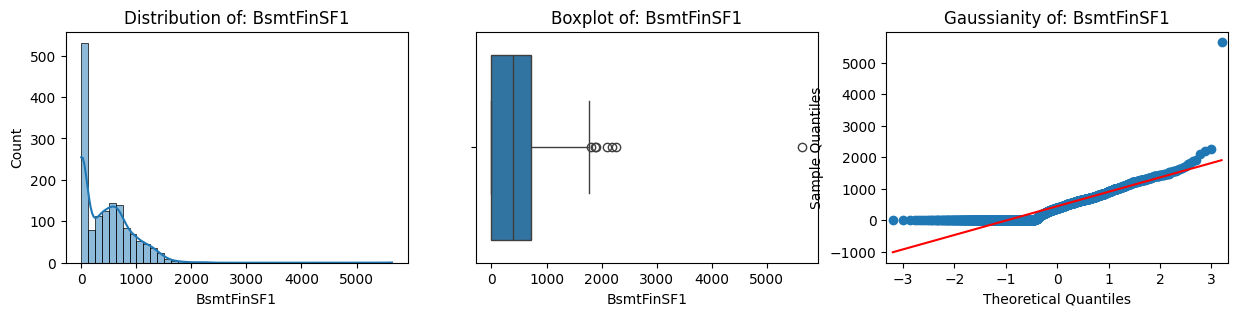

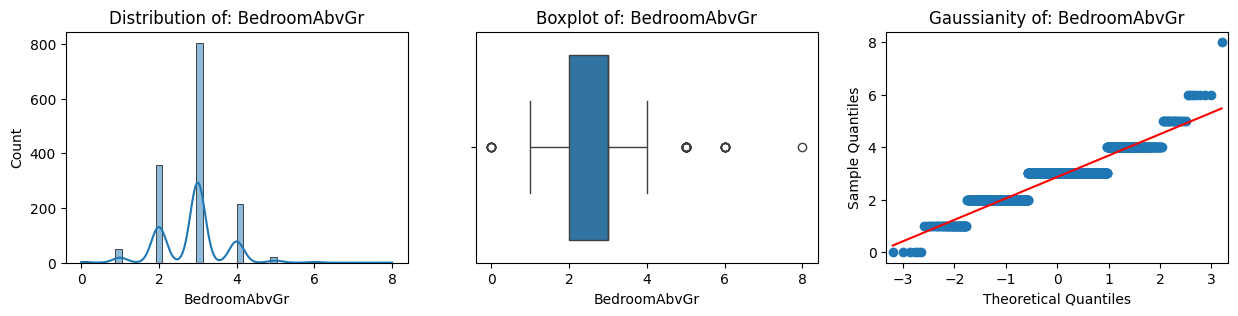

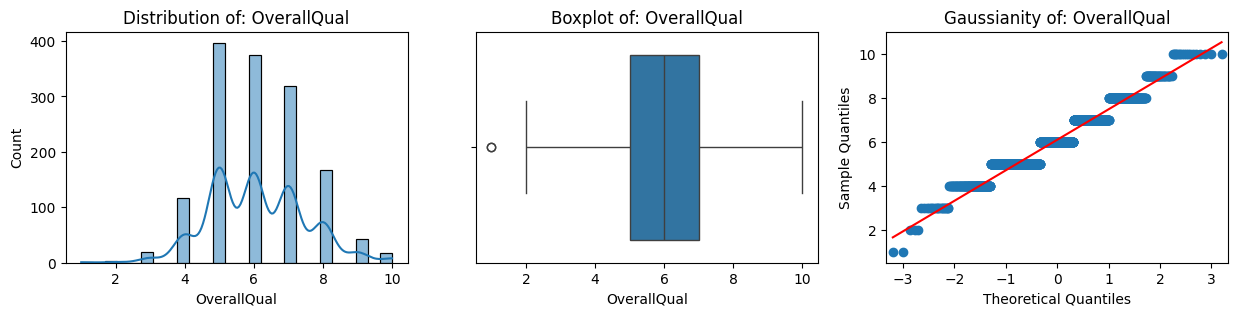

In [ ]:
for numerical_feature in list(set(numerical_features)-set(cyclical_features)):

    # Creating three subplots per numerical_feature
    fig, ax =plt.subplots(1,3,figsize=(15,3))

    # Histogram to get an overview of the distribution of each numerical_feature
    ax[0].set_title(f"Distribution of: {numerical_feature}")
    sns.histplot(data = X_train[numerical_features], x = numerical_feature, kde=True, ax = ax[0]);

    # Boxplot to detect outliers
    ax[1].set_title(f"Boxplot of: {numerical_feature}")
    sns.boxplot(data = X_train[numerical_features], x = numerical_feature, ax=ax[1]);

    # Analyzing whether a feature is normally distributed or not
    ax[2].set_title(f"Gaussianity of: {numerical_feature}")
    qqplot(X_train[numerical_features][numerical_feature],line='s',ax=ax[2]);

    plt.show();

In [ ]:
# OBSERVE THE 3 PLOTS FOR EACH NUM FEATURE
# DECIDE ACCORDINGLY/MANUALLY

# ROBUST
# ---------------------

features_robust = ["MSSubClass", "LotFrontage", "LotArea", "BsmtFinSF1", "BsmtFinSF2",
                   "BsmtUnfSF", "1stFlrSF", "GarageArea","WoodDeckSF", "OpenPorchSF",
                   "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
                   "YrSold"
                  ]

print(f"nb of robust features = {len(features_robust)}")

# STANDARD
# ---------------------

features_standard = ["OverallQual", "TotalBsmtSF", "GrLivArea",]

print(f"nb of standard features = {len(features_standard)}")

# MINMAX
# ---------------------

features_minmax = ["OverallCond","YearBuilt", "YearRemodAdd", "MasVnrArea", "2ndFlrSF",
                   "LowQualFinSF", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
                   "BedroomAbvGr", "KitchenAbvGr","TotRmsAbvGrd","Fireplaces", "GarageYrBlt",
                   "GarageCars"
                  ]

print(f"nb of minmax features = {len(features_minmax)}")

# TOTAL
# ---------------------
print("-"*50)
print(f"nb of scaled features = {len(features_robust) + len(features_standard) + len(features_minmax)}")

nb of robust features = 16
nb of standard features = 3
nb of minmax features = 16
--------------------------------------------------
nb of scaled features = 35


In [ ]:
scalers = ColumnTransformer([
    ("robust_scaler",RobustScaler(),features_robust ),
    ("standard_scaler",StandardScaler(),features_standard),
    ("minmax_scaler",MinMaxScaler(), features_minmax)
])

scalers

ColumnTransformer(transformers=[('robust_scaler', RobustScaler(),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                                  '1stFlrSF', 'GarageArea', 'WoodDeckSF',
                                  'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                                  'ScreenPorch', 'PoolArea', 'MiscVal',
                                  'YrSold']),
                                ('standard_scaler', StandardScaler(),
                                 ['OverallQual', 'TotalBsmtSF', 'GrLivArea']),
                                ('minmax_scaler', MinMaxScaler(),
                                 ['OverallCond', 'YearBuilt', 'YearRemodAdd',
                                  'MasVnrArea', '2ndFlrSF', 'LowQualFinSF',
                                  'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
                                  'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
                                  'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
                                  'GarageCars'])])

In [ ]:
num_pipeline = Pipeline([
    ('num_imputer', SimpleImputer(strategy="median")), # WARNING: VERY NAIVE IMPUTER, BETTER BY NEIGH
    ('scalers', scalers)
]).set_output(transform="pandas")

num_pipeline

Pipeline(steps=[('num_imputer', SimpleImputer(strategy='median')),
                ('scalers',
                 ColumnTransformer(transformers=[('robust_scaler',
                                                  RobustScaler(),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   '1stFlrSF', 'GarageArea',
                                                   'WoodDeckSF', 'OpenPorchSF',
                                                   'EnclosedPorch', '3SsnPorch',
                                                   'ScreenPorch', 'PoolArea',
                                                   'MiscVal', 'YrSold']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['OverallQual', 'TotalBsmtSF',
                                                   'GrLivArea']),
                                                 ('minmax_scaler',
                                                  MinMaxScaler(),
                                                  ['OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   '2ndFlrSF', 'LowQualFinSF',
                                                   'BsmtFullBath',
                                                   'BsmtHalfBath', 'FullBath',
                                                   'HalfBath', 'BedroomAbvGr',
                                                   'KitchenAbvGr',
                                                   'TotRmsAbvGrd', 'Fireplaces',
                                                   'GarageYrBlt',
                                                   'GarageCars'])]))])

In [ ]:
# num_pipeline.fit_transform(X_train.select_dtypes(include=np.number)) #SUCCESS

In [ ]:
num_pipeline[0]

SimpleImputer(strategy='median')

In [ ]:
num_pipeline.named_steps

{'num_imputer': SimpleImputer(strategy='median'),
 'scalers': ColumnTransformer(transformers=[('robust_scaler', RobustScaler(),
                                  ['MSSubClass', 'LotFrontage', 'LotArea',
                                   'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                                   '1stFlrSF', 'GarageArea', 'WoodDeckSF',
                                   'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                                   'ScreenPorch', 'PoolArea', 'MiscVal',
                                   'YrSold']),
                                 ('standard_scaler', StandardScaler(),
                                  ['OverallQual', 'TotalBsmtSF', 'GrLivArea']),
                                 ('minmax_scaler', MinMaxScaler(),
                                  ['OverallCond', 'YearBuilt', 'YearRemodAdd',
                                   'MasVnrArea', '2ndFlrSF', 'LowQualFinSF',
                                   'BsmtFullBath', 'BsmtHalfBath', 'Full

In [ ]:
num_pipeline[1]

ColumnTransformer(transformers=[('robust_scaler', RobustScaler(),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                                  '1stFlrSF', 'GarageArea', 'WoodDeckSF',
                                  'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                                  'ScreenPorch', 'PoolArea', 'MiscVal',
                                  'YrSold']),
                                ('standard_scaler', StandardScaler(),
                                 ['OverallQual', 'TotalBsmtSF', 'GrLivArea']),
                                ('minmax_scaler', MinMaxScaler(),
                                 ['OverallCond', 'YearBuilt', 'YearRemodAdd',
                                  'MasVnrArea', '2ndFlrSF', 'LowQualFinSF',
                                  'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
                                  'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
                                  'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
                                  'GarageCars'])])

In [ ]:
num_pipeline.fit_transform(X_train_num).shape

(1460, 35)

### 🌶️ Full Numerical Transformer **TBC**

In [ ]:
len(list(set(numerical_features)-set(cyclical_features)))

35

In [ ]:
full_numerical_transformer = ColumnTransformer([
    ("cyclical", CyclicalFeatures(), cyclical_features),
    ("numerical", num_pipeline, list(set(numerical_features)-set(cyclical_features)))
], remainder="passthrough")#.set_output(transform="pandas")
full_numerical_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('cyclical', CyclicalFeatures(), ['MoSold']),
                                ('numerical',
                                 Pipeline(steps=[('num_imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scalers',
                                                  ColumnTransformer(transformers=[('robust_scaler',
                                                                                   RobustScaler(),
                                                                                   ['MSSubClass',
                                                                                    'LotFrontage',
                                                                                    'LotArea',
                                                                                    'BsmtFinSF1',
                                                                                    'BsmtFinSF2',
                                                                                    'BsmtUnfSF',
                                                                                    '1stFlrSF',
                                                                                    'GarageArea...
                                  'FullBath', 'HalfBath', 'OpenPorchSF',
                                  'GrLivArea', 'OverallCond', 'MSSubClass',
                                  'YearBuilt', 'WoodDeckSF', 'GarageArea',
                                  'LotFrontage', 'YrSold', 'BsmtFinSF2',
                                  'BsmtFullBath', 'PoolArea', 'BsmtHalfBath',
                                  'MiscVal', 'EnclosedPorch', 'TotalBsmtSF',
                                  'Fireplaces', 'ScreenPorch', 'BsmtUnfSF',
                                  'KitchenAbvGr', 'LowQualFinSF',
                                  'TotRmsAbvGrd', 'GarageYrBlt', '1stFlrSF',
                                  'LotArea', ...])])

In [ ]:
X_train_num.shape

(1460, 36)

In [ ]:
full_numerical_transformer.fit_transform(X_train_num).shape

(1460, 37)

In [ ]:
# full_numerical_transformer.fit_transform(X_train_num)

## 🔡 Categorical Features

In [ ]:
# CATEGORICAL FEATURES
categorical_features = X_train.select_dtypes(include=["object"]).columns
print(f"There are {len(categorical_features)} categorical features:")
display(categorical_features)

There are 43 categorical features:


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
X_train_cat = X_train[categorical_features]
X_train_cat.shape

(1460, 43)

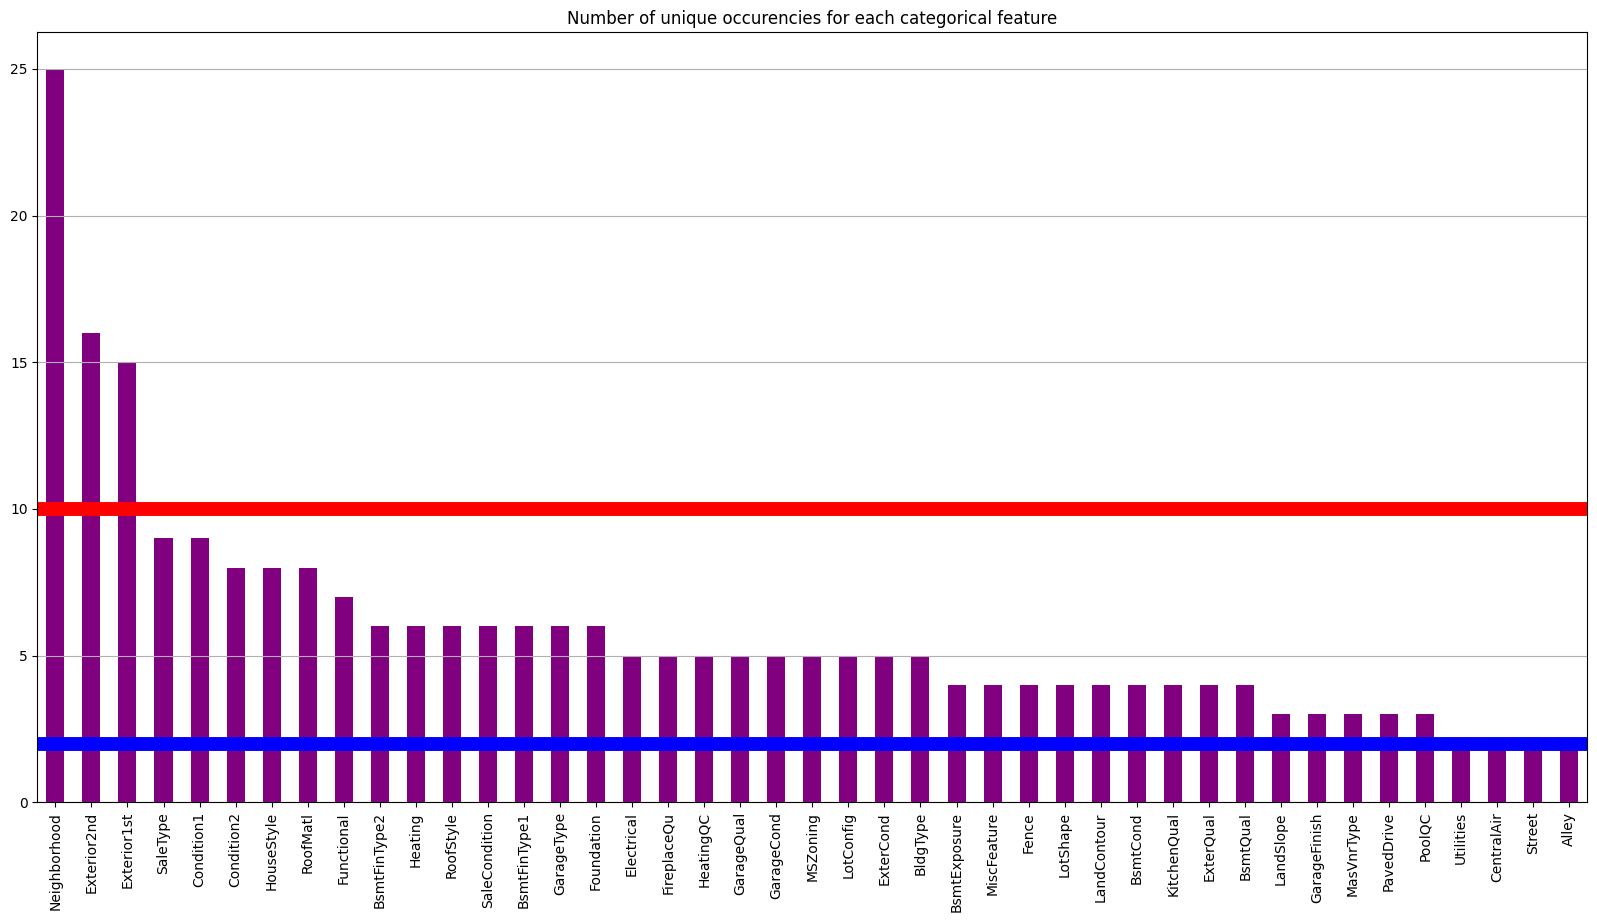

In [ ]:
categorical_occurencies = X_train_cat.nunique().sort_values(ascending = False)
plt.figure(figsize=(20,10))
categorical_occurencies.plot(kind="bar", color="purple")
plt.axhline(2, linestyle='-', linewidth=10,c='blue')
plt.axhline(10, linestyle='-', linewidth=10,c='red')
plt.grid(axis="y")
plt.title("Number of unique occurencies for each categorical feature");
plt.show();

### 💗 Ordinal Features

In [ ]:
feat_ordinal_dict = {
    # considers "missing" as "neutral"
    "Alley":['missing', 'Grvl', 'Pave'],
    "BsmtCond": ['missing', 'Po', 'Fa', 'TA', 'Gd'],
    "BsmtExposure": ['missing', 'No', 'Mn', 'Av', 'Gd'],
    "BsmtFinType1": ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    "BsmtFinType2": ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    "BsmtQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "Electrical": ['missing', 'Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    "ExterCond": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "ExterQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "Fence": ['missing', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    "FireplaceQu": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "Functional": ['missing', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    "GarageCond": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "GarageFinish": ['missing', 'Unf', 'RFn', 'Fin'],
    "GarageQual": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "HeatingQC": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "KitchenQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "LandContour": ['missing', 'Low', 'Bnk', 'HLS', 'Lvl'],
    "LandSlope": ['missing', 'Sev', 'Mod', 'Gtl'],
    "LotShape": ['missing', 'IR3', 'IR2', 'IR1', 'Reg'],
    "PavedDrive": ['missing', 'N', 'P', 'Y'],
    "PoolQC": ['missing', 'Fa', 'Gd', 'Ex'],
}

In [ ]:
ordinal_features = sorted(list(feat_ordinal_dict.keys()))
ordinal_features

['BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'BsmtQual',
 'Electrical',
 'ExterCond',
 'ExterQual',
 'Fence',
 'FireplaceQu',
 'Functional',
 'GarageCond',
 'GarageFinish',
 'GarageQual',
 'HeatingQC',
 'KitchenQual',
 'LandContour',
 'LandSlope',
 'LotShape',
 'PavedDrive',
 'PoolQC']

In [ ]:
ordinal_values = [feat_ordinal_dict[element] for element in ordinal_features]
ordinal_values

[['missing', 'Po', 'Fa', 'TA', 'Gd'],
 ['missing', 'No', 'Mn', 'Av', 'Gd'],
 ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
 ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
 ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Unf', 'RFn', 'Fin'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Low', 'Bnk', 'HLS', 'Lvl'],
 ['missing', 'Sev', 'Mod', 'Gtl'],
 ['missing', 'IR3', 'IR2', 'IR1', 'Reg'],
 ['missing', 'N', 'P', 'Y'],
 ['missing', 'Fa', 'Gd', 'Ex']]

In [ ]:
ordinal_encoder = OrdinalEncoder(categories = ordinal_values,
                                 dtype = np.int64,
                                 handle_unknown='use_encoded_value',
                                 unknown_value=-1)

ordinal_pipeline = Pipeline([
    ('ordinal_imputer', SimpleImputer(strategy="constant", fill_value="missing")),
    ('ordinal_encoder', ordinal_encoder),
    ('minmax', MinMaxScaler())
]).set_output(transform="pandas")

ordinal_pipeline

Pipeline(steps=[('ordinal_imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('ordinal_encoder',
                 OrdinalEncoder(categories=[['missing', 'Po', 'Fa', 'TA', 'Gd'],
                                            ['missing', 'No', 'Mn', 'Av', 'Gd'],
                                            ['missing', 'Unf', 'LwQ', 'Rec',
                                             'BLQ', 'ALQ', 'GLQ'],
                                            ['missing', 'Unf', 'LwQ', 'Rec',
                                             'BLQ', 'ALQ', 'GLQ'],
                                            ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
                                            ['missing', 'Mix', 'Fu...
                                            ['missing', 'Po', 'Fa', 'TA', 'Gd',
                                             'Ex'],
                                            ['missing', 'Po', 'Fa', 'TA', 'Gd',
                                             'Ex'],
                                            ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
                                            ['missing', 'Low', 'Bnk', 'HLS',
                                             'Lvl'],
                                            ['missing', 'Sev', 'Mod', 'Gtl'],
                                            ['missing', 'IR3', 'IR2', 'IR1',
                                             'Reg'],
                                            ['missing', 'N', 'P', 'Y'],
                                            ['missing', 'Fa', 'Gd', 'Ex']],
                                dtype=<class 'numpy.int64'>,
                                handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('minmax', MinMaxScaler())])

In [ ]:
ordinal_pipeline.fit_transform(X_train_cat[ordinal_features])

,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtQual,Electrical,ExterCond,ExterQual,Fence,FireplaceQu,Functional,GarageCond,GarageFinish,GarageQual,HeatingQC,KitchenQual,LandContour,LandSlope,LotShape,PavedDrive,PoolQC
Id,,,,,,,,,,,,,,,,,,,,,
1,0.75,0.25,1.000000,0.166667,0.75,1.0,0.50,0.666667,0.00,0.0,1.000000,0.6,0.666667,0.6,1.00,0.666667,1.0,1.0,1.000000,1.0,0.0
2,0.75,1.00,0.833333,0.166667,0.75,1.0,0.50,0.333333,0.00,0.6,1.000000,0.6,0.666667,0.6,1.00,0.333333,1.0,1.0,1.000000,1.0,0.0
3,0.75,0.50,1.000000,0.166667,0.75,1.0,0.50,0.666667,0.00,0.6,1.000000,0.6,0.666667,0.6,1.00,0.666667,1.0,1.0,0.666667,1.0,0.0
4,1.00,0.25,0.833333,0.166667,0.50,1.0,0.50,0.333333,0.00,0.8,1.000000,0.6,0.333333,0.6,0.75,0.666667,1.0,1.0,0.666667,1.0,0.0
5,0.75,0.75,1.000000,0.166667,0.75,1.0,0.50,0.666667,0.00,0.6,1.000000,0.6,0.666667,0.6,1.00,0.666667,1.0,1.0,0.666667,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,0.75,0.25,0.166667,0.166667,0.75,1.0,0.50,0.333333,0.00,0.6,1.000000,0.6,0.666667,0.6,1.00,0.333333,1.0,1.0,1.000000,1.0,0.0
1457,0.75,0.25,0.833333,0.500000,0.75,1.0,0.50,0.333333,0.75,0.6,0.833333,0.6,0.333333,0.6,0.50,0.333333,1.0,1.0,1.000000,1.0,0.0
1458,1.00,0.25,1.000000,0.166667,0.50,1.0,0.75,1.000000,1.00,0.8,1.000000,0.6,0.666667,0.6,1.00,0.666667,1.0,1.0,1.000000,1.0,0.0


### 🐶 Nominal Features (OHE)

In [ ]:
nominal_features = sorted(list(set(X_train_cat.columns)- set(ordinal_features)))
nominal_features

['Alley',
 'BldgType',
 'CentralAir',
 'Condition1',
 'Condition2',
 'Exterior1st',
 'Exterior2nd',
 'Foundation',
 'GarageType',
 'Heating',
 'HouseStyle',
 'LotConfig',
 'MSZoning',
 'MasVnrType',
 'MiscFeature',
 'Neighborhood',
 'RoofMatl',
 'RoofStyle',
 'SaleCondition',
 'SaleType',
 'Street',
 'Utilities']

In [ ]:
nominal_pipeline = Pipeline([
    ('nominal_imputer', SimpleImputer(strategy="constant", fill_value="missing")), # CAREFUL - NAIVE IMPUTER
    ('ordinal_encoder', OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False))
]).set_output(transform="pandas")

nominal_pipeline

Pipeline(steps=[('nominal_imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('ordinal_encoder',
                 OneHotEncoder(drop='if_binary', handle_unknown='ignore',
                               sparse_output=False))])

In [ ]:
nominal_pipeline.fit_transform(X_train_cat[nominal_features])

,Alley_Grvl,Alley_Pave,Alley_missing,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,CentralAir_Y,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_missing,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_Stone,MasVnrType_missing,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,MiscFeature_missing,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Pave,Utilities_NoSeWa
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0

### 🫑 Full Categorical Transformer

In [ ]:
full_categorical_transformer = ColumnTransformer([
    ("ordinal", ordinal_pipeline, ordinal_features),
    ("nominal", nominal_pipeline, nominal_features)
], remainder = "passthrough").set_output(transform="pandas")

full_categorical_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinal',
                                 Pipeline(steps=[('ordinal_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['missing',
                                                                              'Po',
                                                                              'Fa',
                                                                              'TA',
                                                                              'Gd'],
                                                                             ['missing',
                                                                              'No',
                                                                              'Mn',
                                                                              'Av',
                                                                              'Gd'],
                                                                             ['missing',
                                                                              'Unf',
                                                                              'LwQ',
                                                                              'Rec',
                                                                              'BLQ',
                                                                              'ALQ',
                                                                              'GLQ'],
                                                                             ['missing',
                                                                              'Unf',
                                                                              'LwQ',
                                                                              'Rec',
                                                                              'BLQ...
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Alley', 'BldgType', 'CentralAir',
                                  'Condition1', 'Condition2', 'Exterior1st',
                                  'Exterior2nd', 'Foundation', 'GarageType',
                                  'Heating', 'HouseStyle', 'LotConfig',
                                  'MSZoning', 'MasVnrType', 'MiscFeature',
                                  'Neighborhood', 'RoofMatl', 'RoofStyle',
                                  'SaleCondition', 'SaleType', 'Street',
                                  'Utilities'])])

In [ ]:
full_categorical_transformer.fit_transform(X_train_cat)

## 💈 Full Preprocessor

🛍️ `TODO`:
- The CyclicalFeatures is not "optimisable" through the GridSearchCV
- Let's do it manually first

In [ ]:
# Treat cyclical features
months_in_a_year = 12

X_train['sin_MoSold'] = np.sin(2 * np.pi * (X_train.MoSold - 1) / months_in_a_year)
X_train['cos_MoSold'] = np.cos(2 * np.pi * (X_train.MoSold - 1) / months_in_a_year)

X_train.drop(columns=['MoSold'], inplace=True)
X_train.shape

In [ ]:
full_preprocessor = ColumnTransformer([
    ("NUM", num_pipeline, make_column_selector(dtype_include=["int64", "float64"])),
    ("CAT", full_categorical_transformer, make_column_selector(dtype_include=["object"]))
], remainder = "passthrough").set_output(transform="pandas")

full_preprocessor

In [ ]:
full_preprocessor.fit_transform(X_train).shape

## 🔮 <font color=green>Univariate</font> Feature Selection
*based on their mutual information with target `y`*

<details>
    <summary markdown='span'>🤔 What is mutual information?</summary>
    
- See this <a href="https://twitter.com/ari_seff/status/1409296508634152964">animation</href>

- [Mutual Information](https://en.wikipedia.org/wiki/Mutual_information) is a **statistical** distance between two probability distributions
- Correlation is a **linear** distance between two random variables
- Mutual Information is more general and measures the reduction of uncertainty in Y after observing X.
- On the other hand, if you already know you are working with variables that are smooth (like continuous numerical variables), sometimes correlation may tell you more about them, for instance if their relationship is monotonic.

</details>

<details>
    <summary markdown='span'>🤔 How do we proceed to incorporate this MI test to our <i>full_preprocessor</i>?</summary>

<ul>
    <li>Let's add a <b><i>SelectPercentile</i></b> filter at the end of our <i>full_preprocessor</i> pipeline.    </li>
    <li>This will filter out features that, taken individually, explain the least the variance of our target!    </li>
    <li>The statistical test we recommend passing to SelectPercentile is the <b><i>mutual_info_regression</i></b></li>

</details>


📚 [sklearn.feature_selection.SelectPercentile.html](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectPercentile.html)

In [ ]:
feature_selector = SelectPercentile(
    mutual_info_regression,
    percentile=50,
)
feature_selector

## 🚀 Preprocessor + Feature Selector

In [ ]:
the_preprocessor = Pipeline([
    ("full_preprocessor", full_preprocessor),
    ("feature_selector", feature_selector)
])

the_preprocessor

In [ ]:
full_preprocessor.fit_transform(X_train).shape

In [ ]:
the_preprocessor.fit_transform(X_train, y_train).shape

In [ ]:
round(48/193,2)

In [ ]:
# Re-initialising the preprocessor
the_preprocessor = Pipeline([
    ("full_preprocessor", full_preprocessor),
    ("feature_selector", feature_selector)
])

the_preprocessor

# 🏋🏻‍♂️ MODEL ITERATIONS

## (0) Memory Efficiency

For every regression model we would like to try, we are going to instantiate it through a pipeline as follows:

```python
piped_regression = make_pipeline(preprocessor, regression_model)
```

Technically,
1. The train dataset will go through `the_preprocessor`
2. The regression will be fitted on the preprocessed train dataset!

If we try multiple models, let's save in cache the prepreprocessing operations

```python
piped_regression = make_pipeline(preprocessor, regression_model, memory=cachedir)
```

In [ ]:
cachedir = mkdtemp()

## (1) Testing out different regressors

In [ ]:
%%time
# *********************
# SAVING RESULTS      #
# *********************

final_scores = {
    'model_name': [],
    'score': [],
    'log': []
}

# We can already record the baseline score
final_scores["model_name"].append("Baseline")
final_scores["score"].append(score_baseline)
final_scores["log"].append(True)

# *********************************
# TRYING DIFFERENT REGRESSORS     #
# *********************************

regressors = [
    # LINEAR MODELS
    LinearRegression(), Ridge(), Lasso(),
    # NEIGBHORS
    KNeighborsRegressor(),
    # SUPPORT VECTOR MACHINES
    SVR(kernel="rbf"),
    # ENSEMBLE METHODS
    RandomForestRegressor(), AdaBoostRegressor(), GradientBoostingRegressor(),
    # XGBOOST
    XGBRegressor()
]

for regressor in regressors:
    # MODEL NAME -------------------------------------------
    model_name_temp = str(regressor).split("(")[0]
    print(f"Cross-Validating the {model_name_temp}...")
    # PIPELINED MODEL --------------------------------------
    pipelined_regressor = make_pipeline(the_preprocessor,
                                        regressor,
                                        memory=cachedir)
    cv_results_temp = cross_validate(pipelined_regressor,
                                     X_train, y_train_log,
                                     scoring=rmse_neg,
                                     cv=5
                                    )

    # SAVE RESULTS -----------------------------------------
    final_scores["model_name"].append(model_name_temp)
    final_scores["score"].append(cv_results_temp["test_score"].mean())
    final_scores["log"].append(True)

print("✅ Done! Let's analyze the results")
print("-"*100)
display(round(pd.DataFrame(final_scores).sort_values(by="score", ascending=True),4))

## (2) Fine-Tuning some regressors

In [ ]:
allow_grid_searching = True

In [ ]:
regressor_names = [str(regressor).split("(")[0] for regressor in regressors]
regressor_names

##### Fine-tuning `Ridge`

In [ ]:
if allow_grid_searching:
    # Pipelined Ridge
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    pipelined_ridge = make_pipeline(the_preprocessor,
                                    Ridge(),
                                    memory=cachedir)
    pipelined_ridge.get_params()

    # Hyperparameters to be tuned
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    param_grid =  {'ridge__alpha': np.linspace(0.5, 2, num=20)}

    # Setting up the GridSearch
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    search_ridge = GridSearchCV(estimator = pipelined_ridge,
                                param_grid = param_grid,
                                cv = 5,
                                n_jobs = -1,
                                verbose = 2,
                                scoring=rmse_neg
    )

    # Finding the best hyperparameters
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    search_ridge.fit(X_train, y_train_log);

    final_scores["model_name"].append("Ridge+Tuned")
    final_scores["score"].append(search_ridge.best_score_)
    final_scores["log"].append(True)

##### Fine-tuning `KNeighborsRegressor`

In [ ]:
if allow_grid_searching:
    # Pipelined KNeighborsRegressor
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    pipelined_knr = make_pipeline(the_preprocessor,
                                  KNeighborsRegressor(),
                                  memory=cachedir)

    # Hyperparameters to be tuned
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    param_grid = {'kneighborsregressor__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30]}

    # Setting up the GridSearch
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    search_knr = GridSearchCV(estimator = pipelined_knr,
                              param_grid = param_grid,
                              cv = 5,
                              n_jobs = -1,
                              verbose = 2,
                              scoring=rmse_neg
    )

    # Finding the best hyperparameters
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    search_knr.fit(X_train, y_train_log);

    final_scores["model_name"].append("KNeighborsRegressor+Tuned")
    final_scores["score"].append(search_ridge.best_score_)
    final_scores["log"].append(True)

##### Fine-tuning `SVR`

In [ ]:
if allow_grid_searching:
    # Pipelined SVR
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    pipelined_svr = make_pipeline(the_preprocessor,
                                  SVR(kernel="rbf", C=10),
                                  memory=cachedir)

    # Hyperparameters to be tuned
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    param_grid =  {
        'svr__C': [0.5, 0.7, 1, 2, 5, 10],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
        'svr__coef0': [0.0, 0.1, 0.5,1],
    }

    # Setting up the GridSearch
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    search_svr = GridSearchCV(estimator = pipelined_svr,
                                param_grid = param_grid,
                                cv = 5,
                                n_jobs = -1,
                                verbose = 2,
                                scoring=rmse_neg
    )

    # Finding the best hyperparameters
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    search_svr.fit(X_train, y_train_log);

    final_scores["model_name"].append("SVR+Tuned")
    final_scores["score"].append(search_ridge.best_score_)
    final_scores["log"].append(True)

## (3) Little Digression: XGBoost's Deep Learning tools

In [ ]:
# Create the Validation Set for Early-stopping purposes (XGBOOST and Deep Learning)
X_train_train, X_validation, y_train_train_log, y_validation_log = train_test_split(X_train, y_train_log,
                                                                                    random_state=42)

In [ ]:
# Instantiate Model and Train it
model_xgb_early_stopping = XGBRegressor(max_depth=10,
                                        n_estimators=300,
                                        eval_metric=["rmse"],
                                        learning_rate=0.1,
                                        early_stopping_rounds=10)

model_xgb_early_stopping.fit(
    X_train_preprocessed,
    y_train_train_log,
    verbose=False,
    eval_set=[(X_train_preprocessed, y_train_train_log), (X_validation_preprocessed, y_validation_log)],
)

In [ ]:
# Retrieve performance metrics
results = model_xgb_early_stopping.evals_result()
epochs = len(results['validation_0']["rmse"])
x_axis = range(0, epochs)

# Plot RMSLE loss
fig, ax = plt.subplots()

ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
ax.plot(x_axis, results['validation_1']['rmse'], label='Val')
ax.legend(); plt.ylabel('RMSE (of log)'); plt.title('XGBoost Log Loss')

print("Best Validation Score", min(results['validation_1']['rmse']))

## (4) Stacking

In [ ]:
gboost = GradientBoostingRegressor(n_estimators=100)
ridge = Ridge()
svm = SVR(C=1, epsilon=0.05)
adaboost = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=None))


stacked = VotingRegressor(
    estimators = [("gboost", gboost), ("adaboost", adaboost), ("ridge", ridge), ("svm_rbf", svm)],
    weights = [1, 1, 1, 1], # to equally weight the models
    n_jobs=-1
)

stacked

In [ ]:
pipelined_stacked = make_pipeline(the_preprocessor, stacked)


cv_results_temp = cross_validate(pipelined_stacked,
                                 X_train, y_train_log,
                                 scoring=rmse_neg,
                                 cv=5
                                )

# SAVE RESULTS -----------------------------------------
final_scores["model_name"].append("Stacked")
final_scores["score"].append(cv_results_temp["test_score"].mean())
final_scores["log"].append(True)

## (5) Where are we now?

In [ ]:
display(round(pd.DataFrame(final
                           _scores).sort_values(by="score", ascending=True),4))

# 🎮 PREDICTIONS

## (1) Predict Function

In [ ]:
def pred_to_csv(estimator, name):
    # LOAD TEST DATA
    X_test = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/houses_test_raw.csv")
    X_test_ids = X_test['Id']
    X_test = X_test.drop(columns=['Id'])
    # CYCLICAL FEATURES
    X_test['sin_MoSold'] = np.sin(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)
    X_test['cos_MoSold'] = np.cos(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)
    X_test.drop(columns=['MoSold'], inplace=True)
    # TRAIN
    estimator.fit(X_train,y_train)
    # PREDICT
    y_pred_baseline = estimator.predict(X_test)
    predictions = pd.concat([X_test_ids, pd.Series(y_pred_baseline, name="SalePrice")], axis=1)
    predictions.to_csv(f"{name}.csv", header=True, index=False)

In [ ]:
def pred_to_csv_ylog(estimator, name):
    # LOAD TEST DATA
    X_test = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/houses_test_raw.csv")
    X_test_ids = X_test['Id']
    X_test = X_test.drop(columns=['Id'])
    # CYCLICAL FEATURES
    X_test['sin_MoSold'] = np.sin(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)
    X_test['cos_MoSold'] = np.cos(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)
    X_test.drop(columns=['MoSold'], inplace=True)
    # TRAIN
    estimator.fit(X_train,y_train_log)
    # LOG PRED
    y_pred_log = estimator.predict(X_test)
    # PRED
    y_pred = np.exp(y_pred_log)-1
    predictions = pd.concat([X_test_ids, pd.Series(y_pred, name="SalePrice")], axis=1)
    predictions.to_csv(f"{name}.csv", header=True, index=False)

## (2) Predictions with our best models

### (2.1) No grid

In [ ]:
gradient_reg = make_pipeline(the_preprocessor, GradientBoostingRegressor())
pred_to_csv_ylog(gradient_reg, 'advanced_grad_no_grid')

In [ ]:
xgb_reg = make_pipeline(the_preprocessor, XGBRegressor())
pred_to_csv_ylog(xgb_reg, 'xgb_no_grid')

### (2.2) Fine-Tuning `GradientBoost` and `XGBoost`

##### Fine-tuning `GradientBoostRegressor`

In [ ]:
gradient_reg.get_params()

In [ ]:
param_grid =  {'gradientboostingregressor__alpha': stats.uniform(0.001, 1),
              'gradientboostingregressor__learning_rate': stats.uniform(0.0001, 1),
              'gradientboostingregressor__max_depth': stats.randint(3, 10),
               'gradientboostingregressor__min_samples_leaf': stats.randint(3, 10),
               'gradientboostingregressor__n_estimators': stats.randint(50, 300)
              }


search_grad = RandomizedSearchCV(
        gradient_reg,
        param_grid,
        cv=5,
        n_iter=100,
        n_jobs=-1,
        verbose=2,
        scoring=rmse_neg
    )

search_grad.fit(X_train, y_train_log)
print(f"Best score = {search_grad.best_score_}")
print(f"Best params = {search_grad.best_params_}")

final_scores["model_name"].append("GradientBoostingReg+Tuned")
final_scores["score"].append(search_grad.best_score_)
final_scores["log"].append(True)

In [ ]:
pred_to_csv_ylog(search_grad.best_estimator_, 'advanced_grad_with_grid')

##### Fine-tuning `XGBRegressor`

In [ ]:
xgb_reg.get_params()

In [ ]:
param_grid =  {'xgbregressor__reg_alpha': stats.uniform(0.001, 0.5),
              'xgbregressor__learning_rate': stats.uniform(0.0001, 1),
              'xgbregressor__max_depth': stats.randint(3, 10),
               'xgbregressor__n_estimators': stats.randint(50, 400),
               'xgbregressor__gamma': stats.uniform(0, 0.3)
              }



search_xgb = RandomizedSearchCV(
        xgb_reg,
        param_grid,
        cv=5,
        n_iter=100,
        n_jobs=-1,
        verbose=2,
        scoring=rmse_neg
    )

search_xgb.fit(X_train, y_train_log)
print(f"Best score = {search_xgb.best_score_}")
print(f"Best params = {search_xgb.best_params_}")

final_scores["model_name"].append("XGBReg_Tuned")
final_scores["score"].append(search_grad.best_score_)
final_scores["log"].append(True)

In [ ]:
pred_to_csv_ylog(search_xgb.best_estimator_, 'advanced_grad_with_grid')

# 👀 What if the `y_test` was leaked...?

## (1) Loading the real prices

In [ ]:
data_train.head(2)

In [ ]:
pd.read_csv('AmesHousingTest.txt',sep='\s+')

## (2) Compute the scores myself

# 🎁 Going further

💪 There are some other boosting algorithms that aren't available on Sklearn but are nonetheless pretty great.

👉 [LightGBM](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html) tends to perform even better than XGBoost, but it's not always compatible with Sklearn.

👉 Same with [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor).

🔨 You will need to `pip install` both libraries if you want to experiment with them).

🥇 Most of the top scorers for this competition use either one or the other, if not both.

🤓 I recommend reading [this article](https://machinelearningmastery.com/gradient-boosting-with-scikit-learn-xgboost-lightgbm-and-catboost/), which has examples on how to use all of them.

## (1) LightGBM

In [ ]:
# from lightgbm import LGBMRegressor

# pipelined_light_gbm = make_pipeline(the_preprocessor, LGBMRegressor())
# cv_lgbm = cross_validate(pipe_lgbm, X_train, y_train_log, cv=5, scoring=rmse)

# final_scores['model_name'].append('LightGBM')
# final_scores['score'].append(cv_lgbm['test_score'].mean())
# final_scores['log'].append(True)

## (2) CatBoost

# 🛍️ SHOPPING LIST

**Performance**
* Missing values:imputing by `neighbhorhood`
* Model iterations: `hyperparameter tuning`
* Why is my `gradient_boosting + tune` not the best model (cf. Charlotte's notebook) 🤔?

**Nice to have**
* Integrating the `drop_duplicates` into the `🛠️PREPROCESSOR`
* Being able to use `set_output(transform="pandas")` in my `CyclicalFeatures` class through the `get_feature_names_out`


**Business questions**
* Split the dataset into different markets

**Use the real y_test**
* `plt.plot(X_test, y_test)`
* `plt.plot(X_test, y_pred)`